# Depuración de la matriz completa · TFM Energía UCM

Segundo notebook de depuración. El primero (`03_depuracion_variables.ipynb`) trabaja
sobre la variante `sin_2020` del v5, que **ya venía filtrada** por el constructor:
poda de redundantes, filtro de tendencias, capacidad convertida a cuota y la semana
del apagón borrada. Depurar sobre eso es depurar lo ya depurado, sin ver qué se cayó
por el camino ni por qué.

Este notebook parte de **`dataset_horario_v04.csv`**, la matriz sin podar: 219 columnas,
2020-01-01 → 2026-07-31, con la semana del apagón dentro.

Y la parte "arreglada", en la sección 2: **el bloque `pdbc_*` se retira entero y se
sustituye por el PBF horario**, y **se le añade la meteorología ERA5** que v04 no traía
y las variantes v5 sí. El motivo de las dos cosas está medido allí.

Metodología: la del módulo 06.1 (`Tarea_Eleccionesy_v2.py`), con `funciones_mineria.py`
copiada sin tocar. Cada sección cierra con la tabla de control, para ver la evolución
del dataframe de principio a fin.

## 0 · Configuración y carga

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 220)
plt.rcParams["figure.figsize"] = (12, 5)

REPO = Path("..").resolve()
sys.path.append(str(REPO / "scripts"))

from funciones_mineria import Vcramer                    # librería de clase, sin tocar
import depuracion as dep                                 # adaptaciones a serie horaria
from construir_matriz import construir                   # dataset desde Postgres
from apagon import imputar, VENTANA, RESACA              # el apagón ibérico
from depurar_matriz import depurar, residuo              # nulos, constantes, redundantes
from procedencia import (origen, bloque, con_origen, con_origen_pares,
                         resumen_origen, catalogo)

TARGET = "target_price"
SALIDA_DIR = REPO / "data" / "gold"
# Ventana del apagon para los graficos. Se deriva de `apagon.py` en lugar de repetirla:
# si alli cambia el tramo, aqui cambia la banda roja sola.
APAGON_INI = VENTANA[0].normalize()
APAGON_FIN = RESACA[1].normalize()

### Protocolo de cierre del equipo

De la instrucción de Amgui, y condiciona todo lo que sigue:

> Entrenad hasta el 31-dic-2024 y validad sobre 2025 completo. **No uséis 2026** — lo
> reservamos como conjunto de test y lo abrimos una sola vez el 31 de agosto.

En este notebook eso se traduce en dos reglas mecánicas:

1. **Todo lo que se decide, se decide sobre `train`** (≤ 31-dic-2024): descriptivos,
   umbrales, qué columna cae y cuál no.
2. **2026 no se lee jamás.** Ni para un descriptivo, ni para una correlación, ni para
   medir deriva. La deriva se mide contra 2025, que es validación. Hay una comprobación
   automática al final que lo verifica.

Las filas de 2026 sí viajan en los ficheros de salida — se necesitan el día 31 —, pero
ninguna decisión de este notebook las ha mirado.

In [2]:
# El dataset ya no sale de un CSV: se construye leyendo Postgres. `construir()` envuelve
# al constructor del equipo con los filtros desactivados (la poda la decide este notebook),
# sustituye el bloque `pdbc_*` agregado a media diaria por el horario leído de la tabla, y
# empalma el canal meteorológico. Todo el detalle, en la cabecera de `construir_matriz.py`.
datos = construir()                    # `forzar=True` para releer la base de datos
datos["ts"] = datos["fecha_objetivo"] + pd.to_timedelta(datos["hora"], unit="h")
datos = datos.sort_values("ts").reset_index(drop=True)

TRAIN = datos["split"] == "train"
VAL = datos["split"] == "validation"
TEST = datos["split"] == "test"          # 2026 -- prohibido mirar

print(f"\nForma: {datos.shape[0]:,} filas x {datos.shape[1]} columnas\n")
print(datos.groupby("split", sort=False).agg(
    filas=("ts", "size"), dias=("fecha_objetivo", "nunique"),
    desde=("fecha_objetivo", "min"), hasta=("fecha_objetivo", "max")).to_string())

Leyendo de cache: C:\Users\torgi\proyectos\tfm-energia\data\bronze\matriz_cruda.parquet  (usa forzar=True para reconstruir)

Forma: 57,689 filas x 192 columnas

            filas  dias      desde      hasta
split                                        
train       43867  1828 2020-01-01 2025-01-01
validation   8759   365 2025-01-02 2026-01-01
test         5063   211 2026-01-02 2026-07-31


In [3]:
# ── Tabla de control ───────────────────────────────────────────────────────
# El hilo del notebook: qué se llevó por delante cada decisión.
historial = []


def registrar(etapa, df, cols=None):
    cols = list(df.columns) if cols is None else [c for c in cols if c in df.columns]
    historial.append({
        "etapa": etapa,
        "filas": len(df),
        "columnas": len(cols),
        "celdas_nulas": int(df[cols].isna().sum().sum()),
        "filas_con_nulo": int(df[cols].isna().any(axis=1).sum()),
    })
    return pd.DataFrame(historial)


# Registro de cada descarte, con su motivo. Es lo que se lleva a la memoria.
bitacora = []


def anotar(seccion, variable, motivo, detalle=""):
    bitacora.append({"seccion": seccion, "variable": variable,
                     "motivo": motivo, "detalle": detalle})


registrar("0 · carga v04", datos)

,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,192,659245,49796


## 1 · Objetivos

**Variable objetivo:** `target_price` — precio horario del mercado diario español para
el día D+1. Una fila por (día objetivo, hora), `fecha_objetivo = fecha_pred + 1 día`.

Este notebook **no modela**. Produce dos cosas:

- una **bitácora de descartes** con el motivo de cada columna que cae, y
- **2-3 matrices candidatas** para que el equipo elija con qué entrenar.

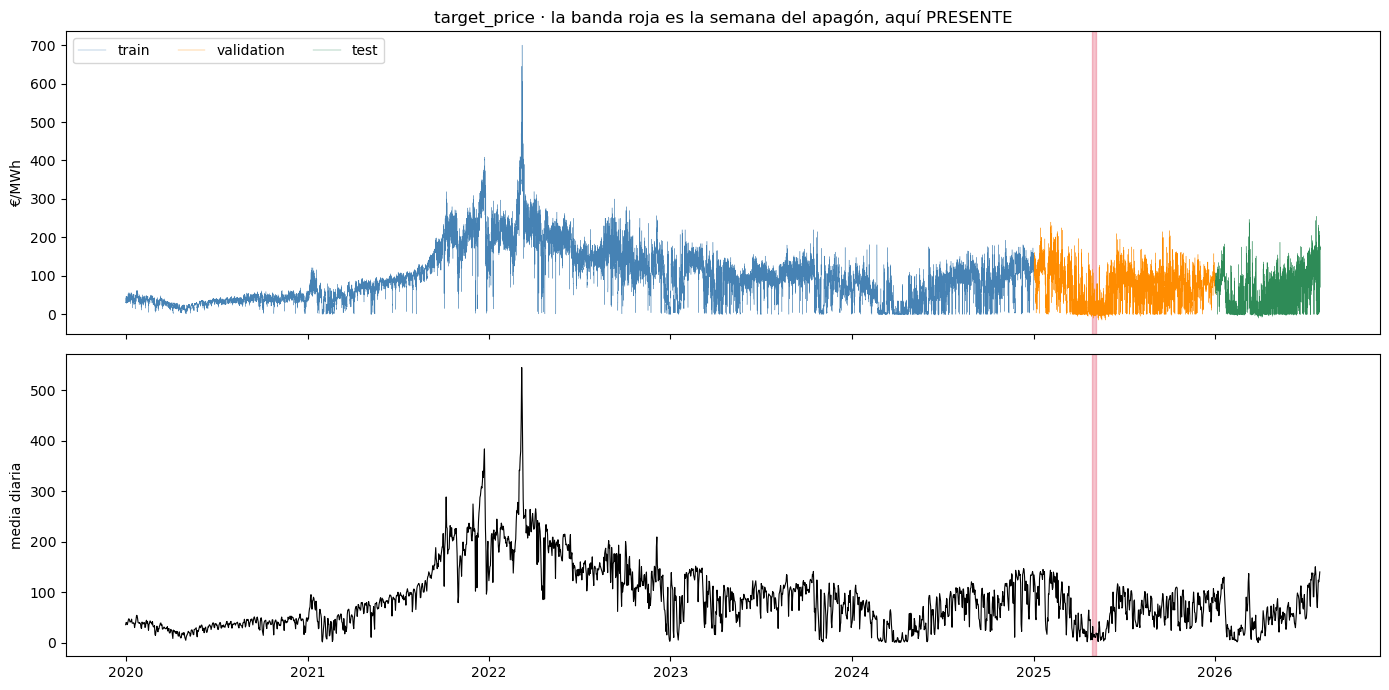

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for s, color in [("train", "steelblue"), ("validation", "darkorange"), ("test", "seagreen")]:
    sub = datos[datos["split"] == s]
    ax[0].plot(sub["ts"], sub[TARGET], lw=0.25, color=color, label=s)
ax[0].axvspan(APAGON_INI, APAGON_FIN, color="crimson", alpha=0.25)
ax[0].set_ylabel("€/MWh"); ax[0].legend(ncol=3)
ax[0].set_title("target_price · la banda roja es la semana del apagón, aquí PRESENTE")

diario = datos.set_index("ts")[TARGET].resample("D").mean()
ax[1].plot(diario.index, diario.values, lw=0.8, color="black")
ax[1].axvspan(APAGON_INI, APAGON_FIN, color="crimson", alpha=0.25)
ax[1].set_ylabel("media diaria")
plt.tight_layout()

## 2 · Reparación de la matriz

Dos pasos, y en este orden. Primero el apagón, que necesita ver los huecos tal cual están;
después la depuración general, que si fuera antes ya habría tapado agujeros que en realidad
había que sustituir enteros.

Los dos viven en scripts (`apagon.py`, `depurar_matriz.py`) y no aquí: son decisiones que
la matriz final tiene que arrastrar consigo, no exploración. Aquí se ejecutan y se mira lo
que hacen.

### 2.1 · El apagón ibérico: sustituir la ventana, rellenar la resaca

El 28 de abril de 2025 a las 12:33 el sistema peninsular se fue a cero. Lo que queda en la
base de datos son tres cosas distintas y hay que tratarlas distinto:

| tramo | qué hay | qué se hace |
|---|---|---|
| 28-abr 12:00 → 1-may 23:00 | dato a ratos, midiendo un sistema cayéndose | **se sustituye entero** por el de 7 días antes |
| 2-may → 7-may | dato bueno, con agujeros de publicación | **solo se rellenan los huecos** |
| 8-may en adelante | dato normal | no se toca |

La sustitución es **en bloque**: todas las columnas del mismo instante de origen, precio
incluido. Sustituir el estado del sistema y dejar el precio real sería lo peor de los dos
mundos — el modelo vería condiciones normales asociadas a 5,79 €/MWh y aprendería una
relación falsa. O se sustituye el bloque entero, o no se sustituye nada.

El calendario **no** se copia: el 1 de mayo es festivo y el 24 de abril no. Copiarlo pondría
"jueves laborable" sobre un festivo.

Y no se reescala ni se añade ruido. Medido contra la verdad tapando periodos completos: el
reescalado gana 1,6 puntos de MAE por columna y a cambio **triplica la incoherencia** entre
variables (1.580 frente a 565, cuando el nivel natural es 508), porque cada columna recibe
un factor distinto y la identidad "total = suma de las partes" deja de cumplirse. El ruido
empeora y no aporta.

In [5]:
datos, informe_apagon = imputar(datos)

print()
print("Efecto sobre el precio, media diaria:")
fo = datos["fecha_objetivo"]
crudo = construir()
crudo["ts"] = crudo["fecha_objetivo"] + pd.to_timedelta(crudo["hora"], unit="h")
crudo = crudo.sort_values("ts").reset_index(drop=True)
vent = (fo >= VENTANA[0].normalize()) & (fo <= RESACA[1].normalize())
comp = pd.DataFrame({
    "real": crudo.loc[vent].groupby(crudo.loc[vent, "fecha_objetivo"])[TARGET].mean(),
    "imputado": datos.loc[vent].groupby(fo[vent])[TARGET].mean(),
}).round(2)
comp["cambia"] = np.where(comp["real"].ne(comp["imputado"]), "sí", "")
display(comp)

registrar("2.1 · apagón imputado", datos)

Ventana 2025-04-28 -> 2025-05-01 · 84 filas · sustitucion en bloque de hace 7 dias
  columnas tocadas : 169
  celdas sustituidas: 14,130
Resaca  2025-05-02 -> 2025-05-07 · 144 filas · solo se rellenan huecos
  columnas con hueco: 13  ->  entsoe_load_Dm6, gen_peninsular_mw_Dm6, wind_mw_Dm6, pumping_cons_mw_Dm6
  celdas rellenadas : 558
  sin reconstruir   : 113

Efecto sobre el precio, media diaria:
Leyendo de cache: C:\Users\torgi\proyectos\tfm-energia\data\bronze\matriz_cruda.parquet  (usa forzar=True para reconstruir)


,real,imputado,cambia
fecha_objetivo,,,
2025-04-28,18.50,40.42,sí
2025-04-29,5.79,64.39,sí
2025-04-30,31.83,44.23,sí
2025-05-01,13.29,43.53,sí
2025-05-02,10.94,10.94,
2025-05-03,16.17,16.17,
2025-05-04,11.00,11.00,
2025-05-05,10.89,10.89,
2025-05-06,10.24,10.24,


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,192,659245,49796
1,2.1 · apagón imputado,57689,194,657300,49679


### 2.2 · Depuración: cada hueco por lo que significa

El principio, y de él sale todo lo demás: **un nulo no es un cero**, y hay que saber cuál es
cuál antes de tocar nada. Poner 0 donde el dato falta inventa un sistema que no existió;
dejar NULL donde el 0 es el valor real tira información buena y obliga a imputar después
algo que ya se sabía.

Las 657.300 celdas nulas de la matriz cruda se separan así:

- **No se imputa, se retira.** Las 8 columnas `*_fc` son la previsión cruda y ya está
  fundida en `*_meteo`; sus nulos son "todavía no había previsiones", no un hueco. Más 5
  `capinst_*` constantes. Entre las dos cosas se va el 45 % de los nulos sin imputar nada.
- **El nulo es un cero, porque la fuente no escribe ceros.** ESIOS usa NULL para "no hubo",
  y se comprueba en que la columna no tiene *ni un* cero explícito en seis años. Marruecos
  y Andorra sin intercambio programado, bilaterales sin contrato, baterías.
- **El nulo es un cero, porque la tecnología no existía.** `capinst_battery_hybrid_mw` no
  tiene dato hasta enero de 2024: antes la capacidad instalada era 0 MW. Tratamiento de
  escalón, no un 0 plano.
- **El nulo es un hueco.** Interpolación temporal acotada a 3 horas; `ffill` en capacidad
  instalada y commodities (los 9 días que faltan **no son fines de semana**, son festivos
  de mercado: un gas a 0 €/MWh sería falso y una interpolación inventaría una cotización);
  y para los huecos largos, la misma hora de hace 7 días, que conserva la forma del día en
  vez de trazar una recta.
- **Lo que no se puede completar se va.** La primera semana no tiene lags de 6 días, y la
  hora 2 del cambio de hora de primavera no existió.

Ni una celda por la media o la mediana de la columna, que es justo lo que se quería evitar.

In [6]:
datos, informe_dep = depurar(datos)

TRAIN = datos["split"] == "train"
VAL = datos["split"] == "validation"
TEST = datos["split"] == "test"

# Las 7 fuentes ERA5 crudas que el canal `*_meteo` sustituye. Se conservan en el dataframe
# pero salen del pool: `*_meteo` dice lo mismo y además cubre toda la serie.
COLS_SUSTITUIDAS = [c for c in datos.columns if c.endswith("_mean_met_Dm1")
                    and c.replace("_mean_met_Dm1", "_meteo") in datos.columns]

print()
print(f"columnas ERA5 crudas que sustituye el canal empalmado: {len(COLS_SUSTITUIDAS)}")
print(f"  {COLS_SUSTITUIDAS}")
registrar("2.2 · depurada", datos)

Retiradas 8 columnas redundantes (`*_fc`, ya en `*_meteo`) y 5 constantes
    constantes: capinst_pump_mw, capinst_autoconsume_battery_mw, capinst_nuclear_mw, capinst_fuel_mw, capinst_ccgt_mw
Descartadas 168 filas de arranque (primeros 7 dias, sin lag posible) y 0 horas inexistentes por el cambio de hora
Matriz: 57,689 x 194  ->  57,521 x 181
Nulos : 657,300 -> 0  (0.000% de la matriz)

Por via de resolucion:
    NULL=0 (convencion de la fuente)              36,559 celdas   14 columnas
    NULL=0 (la serie no existia aun)             184,935 celdas    6 columnas
    NULL=0 (tecnologia inexistente)               92,197 celdas    3 columnas
    NULL=0 (hora que el reloj se salto)               14 celdas    2 columnas
    ffill (escalon / cotizacion vigente)           6,600 celdas    2 columnas
    interpolacion temporal                           831 celdas  111 columnas
    analogo de hace 7 dias (hueco largo)              13 celdas    2 columnas
    sin reconstruir (se declara)         

,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,192,659245,49796
1,2.1 · apagón imputado,57689,194,657300,49679
2,2.2 · depurada,57521,181,0,0


In [7]:
display(con_origen(informe_dep, posicion=1).head(20))

print("Evolución de la matriz:")
display(pd.DataFrame(historial))

,variable,tabla_origen,bloque,nulos_antes,cero_convencion,cero_sin_serie,cero_no_existia,ffill,interpolado,analogo_7d,sin_reconstruir,cero_hora_inexistente
0,ree_gbattery_mw_Dm6,generation (real D-1/D-6),real desfasado,43526,718.0,42808.0,0.0,0.0,0.0,0.0,0,0.0
1,ree_cbattery_mw_Dm6,generation (real D-1/D-6),real desfasado,43526,718.0,42808.0,0.0,0.0,0.0,0.0,0,0.0
2,ree_cbattery_mw_Dm1,generation (real D-1/D-6),real desfasado,43406,718.0,42688.0,0.0,0.0,0.0,0.0,0,0.0
3,ree_gbattery_mw_Dm1,generation (real D-1/D-6),real desfasado,43406,718.0,42688.0,0.0,0.0,0.0,0.0,0,0.0
4,capinst_battery_hybrid_mw,esios_capacity_installed,capacidad,34892,0.0,0.0,34892.0,0.0,0.0,0.0,0,0.0
5,capinst_wind_hybrid_mw,esios_capacity_installed,capacidad,34125,0.0,0.0,27549.0,6576.0,0.0,0.0,0,0.0
6,pbfli_net_flow_ma_mw_D,esios_pbf_load_inter,programa PBF,31182,21462.0,9720.0,0.0,0.0,0.0,0.0,0,0.0
7,capinst_solar_pv_hybrid_mw,esios_capacity_installed,capacidad,29756,0.0,0.0,29756.0,0.0,0.0,0.0,0,0.0
8,bil_direct_consumer_mw_D,esios_pbf_bilateral,programa PBF,9267,5044.0,4223.0,0.0,0.0,0.0,0.0,0,0.0
9,pbfli_net_flow_ad_mw_D,esios_pbf_load_inter,programa PBF,7070,7070.0,0.0,0.0,0.0,0.0,0.0,0,0.0


Evolución de la matriz:


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,192,659245,49796
1,2.1 · apagón imputado,57689,194,657300,49679
2,2.2 · depurada,57521,181,0,0


## 3 · Tipado de variables

Tres grupos, como en la tarea de clase, más uno que allí no existía: las **banderas**
que acabamos de crear, que son metadatos de la fila y no features.

In [8]:
COLS_CONTROL = ["fecha_pred", "fecha_objetivo", "ts", "split"]
# `imputado_apagon` cuenta cuántas celdas de la fila vienen del análogo D-7 y
# `ventana_pisa_apagon` marca las filas cuyos lags alcanzan la ventana. No son features:
# son la trazabilidad de la sección 2.1, y quien evalúe las usa para excluir si quiere.
COLS_BANDERA = [c for c in ["imputado_apagon", "ventana_pisa_apagon",
                            "pbf_publicado_D", "pbf_completo_D"] if c in datos.columns]
# `meteo_es_forecast` NO es bandera de descarte: es una feature de pleno derecho -- le
# dice al modelo si el canal meteorologico de esa fila es prevision o persistencia.
COLS_CATEGORICAS_EXTRA = ["meteo_es_forecast"]
COLS_BINARIAS = ["d1_is_weekend", "d1_is_festivo", "d1_es_puente",
                 "d1_regimen_tope_gas", "d1_regimen_autoconsumo"]
COLS_CATEGORICAS = ["hora", "d1_dow", "d1_month"] + COLS_BINARIAS + COLS_CATEGORICAS_EXTRA

numericas = [c for c in datos.select_dtypes(include="number").columns
             if c not in COLS_CATEGORICAS + COLS_BANDERA + [TARGET]
             and c not in COLS_CONTROL
             # Fuera las dos fuentes meteorologicas originales: las sustituye el canal
             # empalmado `*_meteo` que se construyo en la seccion 2.5.
             and c not in COLS_SUSTITUIDAS]

print(f"Objetivo    : 1")
print(f"Numéricas   : {len(numericas)}")
print(f"Categóricas : {len(COLS_CATEGORICAS)}")
print(f"Banderas    : {len(COLS_BANDERA)}")
print(f"Control     : {len(COLS_CONTROL)}")
print(f"Suma        : {1 + len(numericas) + len(COLS_CATEGORICAS) + len(COLS_BANDERA) + len(COLS_CONTROL)}"
      f" de {datos.shape[1]}")

Objetivo    : 1
Numéricas   : 157
Categóricas : 9
Banderas    : 4
Control     : 4
Suma        : 175 de 181


### Procedencia de cada columna

De aquí en adelante **toda tabla que liste variables lleva su tabla de origen al lado**.
El catálogo vive en `scripts/procedencia.py`: son las mismas reglas que ya usaba el
constructor v5 para colorear el Excel documentado (`ORIGEN_COLUMNAS`), copiadas sin
cambiarlas y ampliadas con el bloque `pbf_*` y con las columnas que nacen aquí.

Un matiz del catálogo heredado que conviene saber leer: las series reales horarias van
todas bajo `generation (real D-1/D-6)` aunque procedan de tres tablas distintas
(`load_inter`, `entsoe_gen_data`, `esios_gen`). Es deliberado — para leer la matriz lo
que importa es que son la misma cosa, el estado real del sistema hora a hora.

In [9]:
cat = catalogo([c for c in datos.columns if c != "ts"])
display(resumen_origen([c for c in datos.columns if c != "ts"]))

,bloque,tabla_origen,columnas
0,calendario,CALENDARIO (calculado),15
1,capacidad,esios_capacity_installed,18
2,capacidad,esios_capacity_available,6
3,casacion PDBC,esios_pdbc_gen,15
4,casacion PDBC,esios_pbf_gen,4
5,combustibles,commodities,3
6,control,CLAVE,4
7,meteorologia,era5_weather_agg,27
8,objetivo,spot_price (TARGET),1
9,otros,DERIVADA (depuracion),3


In [10]:
# Comprobación: ninguna columna debe quedar sin clasificar.
sin_clasificar = cat[cat["tabla_origen"] == "SIN CLASIFICAR"]["variable"].tolist()
print(f"Columnas sin clasificar: {len(sin_clasificar)}  {sin_clasificar}")

print()
print("Desglose del bloque PBF que acabamos de incorporar:")
print(cat[cat["tabla_origen"].str.startswith("esios_pbf")]
      .groupby("tabla_origen").size().rename("columnas").to_string())

registrar("3 · tipado", datos, [TARGET] + numericas + COLS_CATEGORICAS)

Columnas sin clasificar: 0  []

Desglose del bloque PBF que acabamos de incorporar:
tabla_origen
esios_pbf_bilateral      8
esios_pbf_gen            4
esios_pbf_load_inter    10


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,192,659245,49796
1,2.1 · apagón imputado,57689,194,657300,49679
2,2.2 · depurada,57521,181,0,0
3,3 · tipado,57521,166,0,0


## 4 · Análisis descriptivo

`describe()` ampliado con asimetría, curtosis, rango y perdidos — sección 3 de la tarea
de clase — más el % de ceros y de negativos, que en este dominio distinguen una
convención NULL/0 de un balance neto.

**Solo sobre train.**

In [11]:
desc = dep.descriptivo_numericas(datos[TRAIN], numericas)
con_origen(desc.sort_values("%_Missing", ascending=False)).head(25)

,count,tabla_origen,bloque,mean,std,min,25%,50%,75%,max,Asimetria,Kurtosis,Rango,N_Missing,%_Missing,%_Ceros,%_Negativos,N_Distintos
ree_demanda_prev,43699.0,forecast,prevision D+1,26892.641571,4342.592272,8644.00,23398.875,26868.25,30127.000,41615.00,0.136629,-0.636357,32971.00,0,0.0,0.000000,0.000000,27641
ree_gwind_prev,43699.0,forecast,prevision D+1,6676.633097,3849.988802,452.80,3647.000,5899.00,9008.650,20879.30,0.785830,0.015216,20426.50,0,0.0,0.000000,0.000000,25435
ree_gsolar_prev,43699.0,forecast,prevision D+1,3256.404817,4475.778243,0.00,0.000,226.50,5965.650,19526.50,1.276767,0.615890,19526.50,0,0.0,42.760704,0.000000,21504
ree_grenov_prev,43699.0,forecast,prevision D+1,9933.037914,5395.114512,703.50,5638.900,9116.50,13514.900,30951.10,0.637839,-0.130756,30247.60,0,0.0,0.000000,0.000000,36106
es_esios_D,43699.0,spot_price (lag),precio,92.844510,70.294494,-2.00,38.250,82.31,129.520,700.00,1.224485,2.639125,702.00,0,0.0,1.485160,0.565230,15775
pt_entsoe_D,43699.0,"spot_price (Europa, dia D)",precio,93.256364,70.034860,-2.00,38.895,82.66,129.775,651.00,1.227714,2.638725,653.00,0,0.0,1.382183,0.448523,15699
fr_entsoe_D,43699.0,"spot_price (Europa, dia D)",precio,114.611543,117.295068,-134.94,39.570,79.18,145.280,2987.78,2.602692,18.781947,3122.72,0,0.0,0.556077,1.530927,20551
de_lu_entsoe_D,43699.0,"spot_price (Europa, dia D)",precio,107.488090,104.533600,-500.00,41.710,82.00,129.915,936.28,2.239061,6.782536,1436.28,0,0.0,0.235703,2.892515,20121
it_nord_entsoe_D,43699.0,"spot_price (Europa, dia D)",precio,141.460963,116.527739,0.00,64.150,109.57,177.860,871.00,2.012039,5.087402,871.00,0,0.0,0.011442,0.000000,18785
ch_entsoe_D,43699.0,"spot_price (Europa, dia D)",precio,123.015663,111.818293,-427.51,48.910,87.60,159.190,871.61,1.918823,4.531588,1299.12,0,0.0,0.004577,1.109865,21887


In [12]:
print("--- Objetivo (train) ---")
print(datos.loc[TRAIN, TARGET].describe().to_string())
print(f"\nAsimetría {datos.loc[TRAIN, TARGET].skew():.2f} · "
      f"Curtosis {datos.loc[TRAIN, TARGET].kurtosis():.2f}")
print(f"Horas a precio <= 0: {(datos.loc[TRAIN, TARGET] <= 0).sum():,} "
      f"({(datos.loc[TRAIN, TARGET] <= 0).mean() * 100:.2f}%)")

--- Objetivo (train) ---
count    43699.000000
mean        92.874961
std         70.295432
min         -2.000000
25%         38.250000
50%         82.440000
75%        129.620000
max        700.000000

Asimetría 1.22 · Curtosis 2.64
Horas a precio <= 0: 896 (2.05%)


## 5 · Corrección de errores detectados

### 5.1 · Nulo de tecnología = cero — verificación

La regla del equipo, y es la correcta: si una tecnología no existía o no generó, su nulo
vale **cero**, y la columna **se conserva** aunque quede casi toda a cero. Una batería en
2021 no es un dato ausente: es una batería que no existía y generaba 0 MW.

La regla ya está aplicada — vive en `depurar_matriz.py` y se ejecutó en la sección 2.2,
porque tiene que viajar con la matriz y no quedarse en el notebook. Aquí se **comprueba**,
que es distinto: lo que hay que poder defender no es que se aplicara, sino que se aplicara
sólo donde tocaba.

**Dos excepciones**, porque ahí el nulo no es un cero:

- **Nuclear.** Mínimo publicado 50 MW, percentil 1 en 2.061 MW, cero horas a 0 en seis
  años. Un sistema sin nuclear no existe: ese nulo es falta de publicación, y por eso la
  suya se resolvió con el análogo del apagón, no con un 0.
- **Demanda, precios, flujos, commodities y meteorología.** No son tecnologías; un cero
  ahí sería un dato inventado.

In [13]:
# Qué columnas recibieron el tratamiento NULL -> 0, y por qué vía.
vias_cero = [v for v in ("cero_convencion", "cero_sin_serie", "cero_no_existia")
             if v in informe_dep.columns]
recibieron = informe_dep[informe_dep[vias_cero].sum(axis=1) > 0]
display(con_origen(recibieron[["variable", "nulos_antes"] + vias_cero], posicion=1))

# Las dos excepciones, comprobadas y no supuestas.
NO_APLICA = ("nuclear", "load", "demand", "netflow", "net_flow", "ntc", "gas_",
             "co2_", "es_esios", "capdisp_", "total_gen", "unavailable", "target")
violan = [c for c in recibieron["variable"]
          if any(p in c for p in NO_APLICA)
          and not c.startswith(("pbfli_net_flow_ma", "pbfli_net_flow_ad"))]
print(f"Columnas que NO son tecnología y aun así recibieron ceros: {len(violan)}")
if violan:
    print(f"    {violan}   <- revisar")

nuc = [c for c in datos.columns if "nuclear" in c and c.startswith("pdbc_")]
for c in nuc:
    n0 = int((datos[c] == 0).sum())
    print(f"  {c:28s} horas a cero: {n0}  (debe ser 0: la nuclear nunca para del todo)")

print()
print("Marruecos y Andorra sí llevan ceros a propósito: su NULL es la convención de la")
print("fuente para 'sin intercambio programado'. La sección 9 separa cuántos de esos")
print("ceros son convención y cuántos son tramo sin serie.")

,variable,tabla_origen,bloque,nulos_antes,cero_convencion,cero_sin_serie,cero_no_existia
0,ree_gbattery_mw_Dm6,generation (real D-1/D-6),real desfasado,43526,718.0,42808.0,0.0
1,ree_cbattery_mw_Dm6,generation (real D-1/D-6),real desfasado,43526,718.0,42808.0,0.0
2,ree_cbattery_mw_Dm1,generation (real D-1/D-6),real desfasado,43406,718.0,42688.0,0.0
3,ree_gbattery_mw_Dm1,generation (real D-1/D-6),real desfasado,43406,718.0,42688.0,0.0
4,capinst_battery_hybrid_mw,esios_capacity_installed,capacidad,34892,0.0,0.0,34892.0
5,capinst_wind_hybrid_mw,esios_capacity_installed,capacidad,34125,0.0,0.0,27549.0
6,pbfli_net_flow_ma_mw_D,esios_pbf_load_inter,programa PBF,31182,21462.0,9720.0,0.0
7,capinst_solar_pv_hybrid_mw,esios_capacity_installed,capacidad,29756,0.0,0.0,29756.0
8,bil_direct_consumer_mw_D,esios_pbf_bilateral,programa PBF,9267,5044.0,4223.0,0.0
9,pbfli_net_flow_ad_mw_D,esios_pbf_load_inter,programa PBF,7070,7070.0,0.0,0.0


Columnas que NO son tecnología y aun así recibieron ceros: 0
  pdbc_nuclear_mw_D            horas a cero: 111  (debe ser 0: la nuclear nunca para del todo)

Marruecos y Andorra sí llevan ceros a propósito: su NULL es la convención de la
fuente para 'sin intercambio programado'. La sección 9 separa cuántos de esos
ceros son convención y cuántos son tramo sin serie.


### 5.2 · Columnas constantes en train

Sin varianza no hay nada que aprender, y en los modelos lineales además rompe la
inversión de la matriz. Se mide **sobre train**: una columna puede moverse en 2026 y
ser plana en el periodo de entrenamiento, y eso es igual de inútil.

In [14]:
distintos = datos.loc[TRAIN, numericas].nunique()
constantes = distintos[distintos <= 1].index.tolist()
casi = distintos[(distintos > 1) & (distintos <= 2)].index.tolist()

for c in constantes:
    print(f"  CONSTANTE  {c:34s} valor={datos.loc[TRAIN, c].dropna().unique()[:1]}")
    anotar("5.2", c, "constante en train", "un solo valor distinto")
for c in casi:
    print(f"  CUASI      {c:34s} valores={sorted(datos.loc[TRAIN, c].dropna().unique())}")
    anotar("5.2", c, "cuasi-constante en train", "dos valores distintos")

fuera_52 = constantes + casi
numericas = [c for c in numericas if c not in fuera_52]
print(f"\n{len(fuera_52)} fuera. Numéricas restantes: {len(numericas)}")
registrar("5.2 · constantes", datos, [TARGET] + numericas + COLS_CATEGORICAS)

  CONSTANTE  pdbc_fuel_gas_mw_D                 valor=[0.]
  CUASI      capinst_waste_renewable_mw         valores=[np.float64(118.84), np.float64(131.63)]
  CUASI      capdisp_fuel_mw                    valores=[np.float64(7.9), np.float64(7.900000000000001)]
  CUASI      d1_vispera_festivo                 valores=[np.int64(0), np.int64(1)]

4 fuera. Numéricas restantes: 153


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,192,659245,49796
1,2.1 · apagón imputado,57689,194,657300,49679
2,2.2 · depurada,57521,181,0,0
3,3 · tipado,57521,166,0,0
4,5.2 · constantes,57521,162,0,0


### 5.3 · Colinealidad exacta por construcción

Sumas y totales que reproducen exactamente otras columnas. No es correlación alta: es
identidad. Se comprueba en vez de darla por supuesta.

In [15]:
IDENTIDADES = [
    ("gen_renovables_prev_mw", ["gen_wind_prev_mw", "gen_solar_pv_prev_mw"]),
    ("pbf_total_hydro_mw_D", ["pbf_hydro_ugh_mw_D", "pbf_hydro_no_ugh_mw_D"]),
    ("capinst_total_mw", ["capinst_total_renewable_mw", "capinst_total_nonrenewable_mw"]),
]

fuera_53 = []
for total, partes in IDENTIDADES:
    if total not in datos.columns or any(p not in datos.columns for p in partes):
        continue
    dif = (datos[total] - datos[partes].sum(axis=1)).abs()
    exacta = dif.max() < 1e-6
    print(f"  {total:32s} = {' + '.join(partes)}")
    print(f"      diferencia máxima {dif.max():.6f}  ->  "
          f"{'IDENTIDAD EXACTA, se retira el total' if exacta else 'no es identidad, se conserva'}")
    if exacta:
        fuera_53.append(total)
        anotar("5.3", total, "colinealidad exacta", f"= {' + '.join(partes)}")

numericas = [c for c in numericas if c not in fuera_53]
print(f"\n{len(fuera_53)} fuera. Numéricas restantes: {len(numericas)}")
registrar("5.3 · colinealidad exacta", datos, [TARGET] + numericas + COLS_CATEGORICAS)

  capinst_total_mw                 = capinst_total_renewable_mw + capinst_total_nonrenewable_mw
      diferencia máxima 0.010000  ->  no es identidad, se conserva

0 fuera. Numéricas restantes: 153


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,192,659245,49796
1,2.1 · apagón imputado,57689,194,657300,49679
2,2.2 · depurada,57521,181,0,0
3,3 · tipado,57521,166,0,0
4,5.2 · constantes,57521,162,0,0
5,5.3 · colinealidad exacta,57521,162,0,0


### 5.4 · Sin equivalente en producción: la racha de viento

`wind_gust10` es la velocidad máxima instantánea, frente al viento medio sostenido.
Importa porque los aerogeneradores tienen velocidad de corte —sobre 25 m/s se paran por
seguridad— y lo que dispara esa parada es la racha, no la media.

Se retira de la matriz por dos motivos que se refuerzan.

**No está en la previsión.** El archivo de Open-Meteo no la sirve (`wind_gusts_10m_previous_day1`
responde pero devuelve nulos, verificado 28-ago-2026). El histórico de previsión la trae
vacía en sus 20.952 filas. Mantenerla obligaría a reconstruirla con una fórmula en
entrenamiento mientras producción usa el dato real del cron: cambiar un hueco por una
inconsistencia, que es peor.

**Y agregada no aporta casi nada.** Medido sobre las 19.039 horas de ERA5 que sí la tienen:

| | |
|---|---|
| r(racha, viento 10 m) | **0,971** |
| R² de racha ~ viento10 | **0,943** |
| ratio racha/media | 1,825 ± 0,162 |
| residuo tras el ajuste | 0,54 m/s sobre una media de 7,04 |

Es viento medio multiplicado por 1,8. El motivo es la propia agregación: la racha es un
fenómeno **local**, y promediar sobre 1.881 celdas la diluye hasta desaparecer. El máximo
del dominio en seis años son 19,3 m/s y **cero horas superan el umbral de corte**, así que
la columna no puede capturar el mecanismo que la haría valiosa.

Queda anotado como mejora futura: agregando por **máximo** del dominio en vez de por media,
la racha sí detectaría los cortes. Requiere el tensor, y solo sería posible para ERA5.

In [16]:
gust = [c for c in numericas if "gust" in c.lower()]
for c in gust:
    print(f"  fuera: {c}")
    anotar("5.4", c, "sin equivalente en produccion",
           "no archivada en la prevision; R2=0.94 frente al viento medio")

numericas = [c for c in numericas if c not in gust]
print()
print(f"{len(gust)} fuera. Numéricas restantes: {len(numericas)}")
registrar("5.4 · racha de viento", datos, [TARGET] + numericas + COLS_CATEGORICAS)

  fuera: wind_gust10_mean_met_Dm1
  fuera: wind_gust10_mean_met_Dm2

2 fuera. Numéricas restantes: 151


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,192,659245,49796
1,2.1 · apagón imputado,57689,194,657300,49679
2,2.2 · depurada,57521,181,0,0
3,3 · tipado,57521,166,0,0
4,5.2 · constantes,57521,162,0,0
5,5.3 · colinealidad exacta,57521,162,0,0
6,5.4 · racha de viento,57521,160,0,0


### 5.5 · Deriva train → validación

Las columnas de capacidad instalada son tendencias monótonas: el parque solar y de
baterías crece cada año, la cogeneración se retira. Una variable cuyo rango en
validación no se solapa con el de train es una extrapolación, no una predicción.

Se mide como desplazamiento tipificado de la media, `(media_val − media_train) / sd_train`.
**Contra 2025, nunca contra 2026.**

In [17]:
mu_tr, sd_tr = datos.loc[TRAIN, numericas].mean(), datos.loc[TRAIN, numericas].std()
deriva = ((datos.loc[VAL, numericas].mean() - mu_tr) / sd_tr.replace(0, np.nan))
deriva = deriva.dropna().sort_values(key=np.abs, ascending=False)

print("Las 20 mayores derivas (en sigmas de train):")
print(deriva.head(20).round(2).to_string())

UMBRAL_DERIVA = 3.0
muy_derivadas = deriva[deriva.abs() > UMBRAL_DERIVA].index.tolist()
print(f"\nPor encima de {UMBRAL_DERIVA} sigmas: {len(muy_derivadas)} columnas.")
print("NO se eliminan aquí: entran marcadas y son el criterio que separa la matriz")
print("`nucleo` de la `completa` en la sección 12.")

Las 20 mayores derivas (en sigmas de train):
capinst_cogeneration_mw           -7.68
capinst_other_renewable_mw         7.60
ree_cbattery_mw_Dm1               -6.31
ree_cbattery_mw_Dm6               -6.21
ree_gbattery_mw_Dm1                5.89
capinst_hydro_mw                  -5.87
ree_gbattery_mw_Dm6                5.80
capinst_total_hybrid_mw            3.45
capinst_solar_pv_hybrid_mw         3.43
pdbc_hybrid_mw_D                   3.18
capinst_battery_hybrid_mw          3.01
capinst_autoconsume_solar_pv_mw    3.01
capinst_total_mw                   2.95
capinst_solar_pv_mw                2.77
pbfli_demand_aux_mw_D              2.75
capinst_total_renewable_mw         2.68
capinst_total_autoconsume_mw       2.61
capinst_wind_mw                    2.07
capinst_wind_hybrid_mw             1.80
pdbc_biogas_mw_D                  -1.64

Por encima de 3.0 sigmas: 12 columnas.
NO se eliminan aquí: entran marcadas y son el criterio que separa la matriz
`nucleo` de la `completa` en la sección

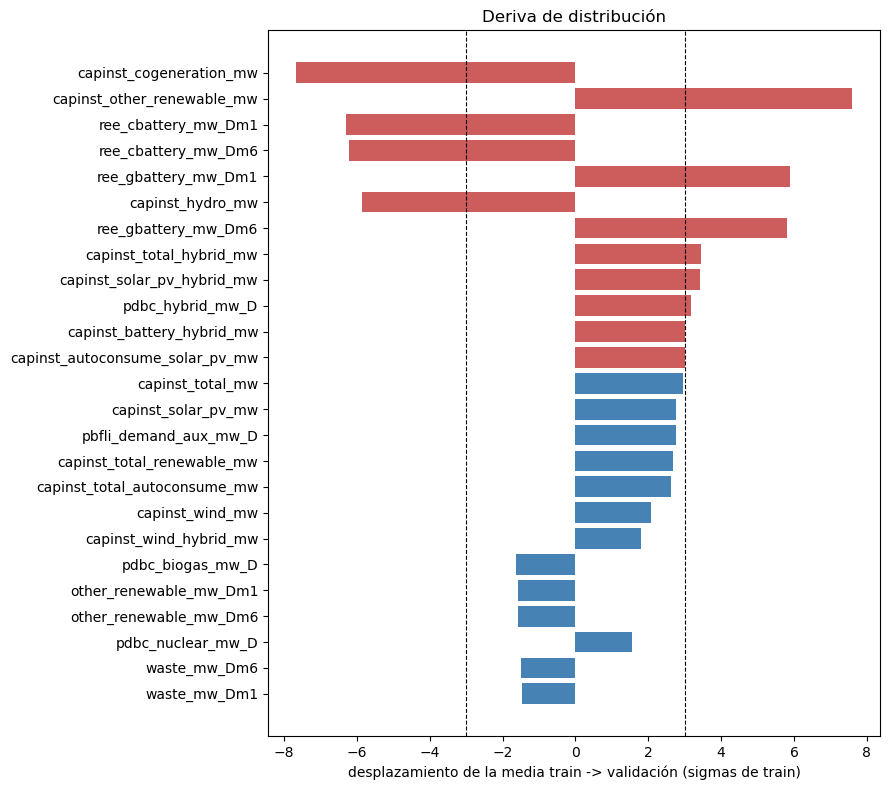

In [18]:
plt.figure(figsize=(9, 8))
top = deriva.head(25).iloc[::-1]
plt.barh(top.index, top.values,
         color=["indianred" if abs(v) > UMBRAL_DERIVA else "steelblue" for v in top.values])
plt.axvline(UMBRAL_DERIVA, ls="--", color="black", lw=0.8)
plt.axvline(-UMBRAL_DERIVA, ls="--", color="black", lw=0.8)
plt.xlabel("desplazamiento de la media train -> validación (sigmas de train)")
plt.title("Deriva de distribución")
plt.tight_layout()

## 6 · Separación de objetivo e inputs

`es_esios_D`, `es_esios_Dm1` y `es_esios_Dm6` son el precio en días anteriores. Son
features legítimas y potentísimas — `es_esios_D` es la persistencia, la referencia
contra la que se mide todo — pero se apartan del pool para que el ranking de la
sección 11 hable del resto. Si no, solo hablan ellas.

In [19]:
persistencia = [c for c in numericas if c.startswith("es_esios_")]
variables_input = [c for c in numericas if c not in persistencia]

print(f"Objetivo            : {TARGET}")
print(f"Persistencia        : {len(persistencia)}  {persistencia}")
print(f"Pool de candidatas  : {len(variables_input)}")
print(f"Categóricas         : {len(COLS_CATEGORICAS)}")

Objetivo            : target_price
Persistencia        : 3  ['es_esios_D', 'es_esios_Dm1', 'es_esios_Dm6']
Pool de candidatas  : 148
Categóricas         : 9


## 7 · Valores atípicos

Criterio de clase (`atipicosAmissing`): atípico solo si cumple **a la vez** `|z| > 3`
(o `|MAD| > 8` si es asimétrica) **y** queda fuera de `Q1 − 3·IQR` / `Q3 + 3·IQR`.

**No se aplica el tratamiento de clase.** En la tarea de elecciones los atípicos se
pasaban a *missing* y se imputaban; aquí una hora a 300 €/MWh en una ola de calor sin
viento es justo el caso que hay que acertar. Se diagnostica y se ordena.

,variable,tabla_origen,bloque,n_atipicos,pct_atipicos,asimetria,minimo
0,capdisp_coal_antracita_mw,esios_capacity_available,capacidad,15790,36.133550,2.611843,230.00
1,capinst_solar_pv_hybrid_mw,esios_capacity_installed,capacidad,8807,20.153779,1.799776,0.00
2,capinst_battery_hybrid_mw,esios_capacity_installed,capacidad,8807,20.153779,1.794945,0.00
3,capinst_total_hybrid_mw,esios_capacity_installed,capacidad,5160,11.808051,1.593626,11.58
4,pdbc_hybrid_mw_D,esios_pdbc_gen,casacion PDBC,4536,10.380100,5.086039,0.00
5,pdbc_pumping_cons_mw_D,esios_pbf_gen,casacion PDBC,4401,10.071169,-2.001781,-4452.00
6,spread_es_fr_D,spot_price (lag),precio,3843,8.794252,-4.297420,-2701.70
7,pdbc_pumping_gen_mw_D,esios_pbf_gen,casacion PDBC,2884,6.599693,2.029259,0.00
8,pdbc_coal_mw_D,esios_pdbc_gen,casacion PDBC,2137,4.890272,1.835768,0.00
9,spread_es_pt_D,spot_price (lag),precio,1781,4.075608,-10.450103,-122.39


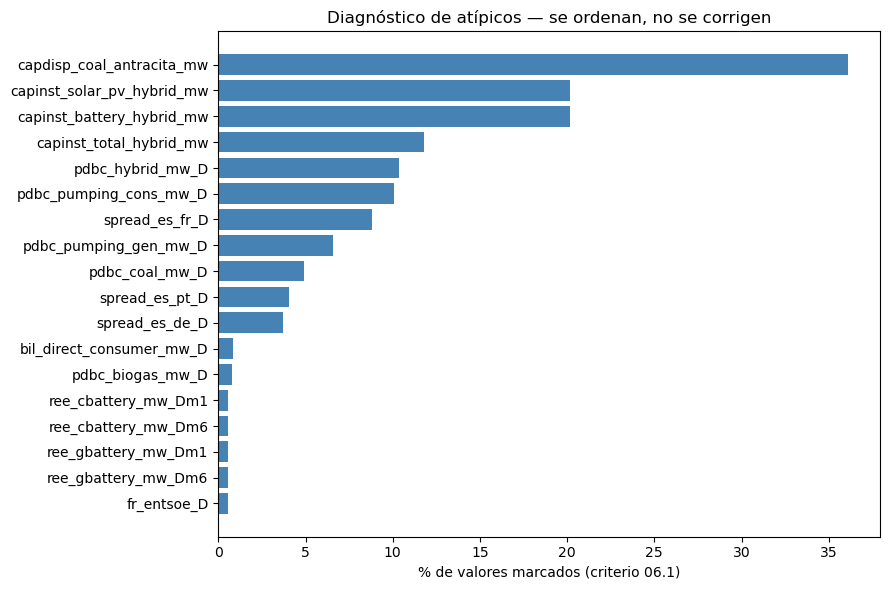

In [20]:
atipicos = dep.diagnostico_atipicos(datos[TRAIN], variables_input + [TARGET])
display(con_origen(atipicos[atipicos["n_atipicos"] > 0]).head(20))

top = atipicos[atipicos["n_atipicos"] > 0].head(18).iloc[::-1]
if len(top):
    plt.figure(figsize=(9, 6))
    plt.barh(top["variable"], top["pct_atipicos"],
             color=["indianred" if v == TARGET else "steelblue" for v in top["variable"]])
    plt.xlabel("% de valores marcados (criterio 06.1)")
    plt.title("Diagnóstico de atípicos — se ordenan, no se corrigen")
    plt.tight_layout()

## 8 · Valores perdidos

Ya no queda ninguno: la sección 2.2 los resolvió todos. Lo que se revisa aquí es **cómo** se
resolvieron, que es lo que hay que poder defender en la memoria. Una matriz sin nulos no
dice nada por sí sola — lo que importa es que ninguno se tapó con un estadístico global.

In [21]:
vias = [c for c in informe_dep.columns
        if c not in ("variable", "nulos_antes", "sin_reconstruir")]
resumen_vias = (informe_dep[vias].sum().rename("celdas").to_frame()
                .assign(columnas=[int((informe_dep[v] > 0).sum()) for v in vias]))
resumen_vias["% de los nulos"] = (
    resumen_vias["celdas"] / informe_dep["nulos_antes"].sum() * 100).round(1)
display(resumen_vias[resumen_vias["celdas"] > 0])

print(f"Nulos que quedan en toda la matriz: {int(datos.isna().sum().sum())}")
print(f"Días incompletos: {len(residuo(datos))}")
print()
print("Ninguna celda imputada por media o mediana de columna.")

for _, r in informe_dep.iterrows():
    if r.get("cero_convencion", 0):
        anotar("8", r["variable"], "NULL = 0 por convención de la fuente",
               f"{int(r['cero_convencion']):,} celdas")

registrar("8 · sin nulos", datos)

,celdas,columnas,% de los nulos
cero_convencion,36559.0,14,11.4
cero_sin_serie,184935.0,6,57.6
cero_no_existia,92197.0,3,28.7
ffill,6600.0,2,2.1
interpolado,831.0,111,0.3
analogo_7d,13.0,2,0.0
cero_hora_inexistente,14.0,2,0.0


Nulos que quedan en toda la matriz: 0
Días incompletos: 0

Ninguna celda imputada por media o mediana de columna.


,etapa,filas,columnas,celdas_nulas,filas_con_nulo
0,0 · carga v04,57689,192,659245,49796
1,2.1 · apagón imputado,57689,194,657300,49679
2,2.2 · depurada,57521,181,0,0
3,3 · tipado,57521,166,0,0
4,5.2 · constantes,57521,162,0,0
5,5.3 · colinealidad exacta,57521,162,0,0
6,5.4 · racha de viento,57521,160,0,0
7,8 · sin nulos,57521,181,0,0


### 8.1 · El patrón de perdidos, antes de repararlo

La forma en que faltan los datos es informativa por sí misma: si dos columnas faltan
*exactamente* en las mismas filas, no son dos fallos, es uno solo visto dos veces. Es lo que
justifica un testigo por patrón de ausencia y no uno por columna.

En la matriz cruda: 142 columnas con algún perdido, 659,245 celdas (5.95%)


,variable,tabla_origen,bloque,pct_nulos
0,ree_cbattery_mw_Dm6,generation (real D-1/D-6),real desfasado,75.74
1,ree_gbattery_mw_Dm6,generation (real D-1/D-6),real desfasado,75.74
2,ree_cbattery_mw_Dm1,generation (real D-1/D-6),real desfasado,75.53
3,ree_gbattery_mw_Dm1,generation (real D-1/D-6),real desfasado,75.53
4,wind10_fc,ecmwf_forecast_agg (prevision D+1),meteorologia,64.56
5,wind100_fc,ecmwf_forecast_agg (prevision D+1),meteorologia,64.56
6,t2m_fc,ecmwf_forecast_agg (prevision D+1),meteorologia,64.56
7,d2m_fc,ecmwf_forecast_agg (prevision D+1),meteorologia,64.56
8,tp_fc,ecmwf_forecast_agg (prevision D+1),meteorologia,64.56
9,msl_fc,ecmwf_forecast_agg (prevision D+1),meteorologia,64.56


Perdidos agrupados por tabla de origen:
                                    columnas   peor
tabla_origen                                       
DERIVADA (testigo de publicacion)          2   0.05
commodities                                3   0.17
ecmwf_forecast_agg (prevision D+1)         8  64.56
era5_weather_agg                          27   0.14
esios_capacity_installed                   4  60.77
esios_pbf_bilateral                        8  16.39
esios_pbf_gen                              4   0.12
esios_pbf_load_inter                      10  54.42
esios_pdbc_gen                            15   0.26
forecast                                   1   0.00
generation (real D-1/D-6)                 44  75.74
spot_price (Europa, dia D)                10   0.06
spot_price (lag)                           6   0.30


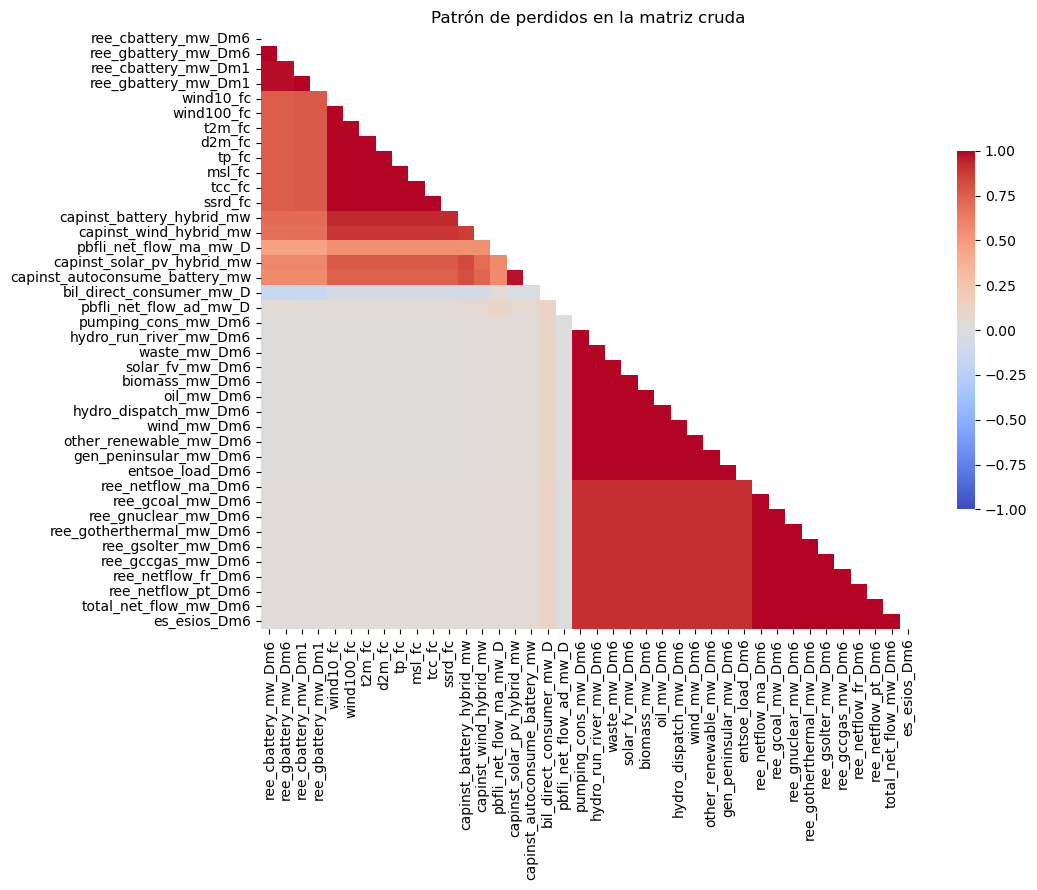

In [22]:
nulos_crudo = crudo.isna().mean()
con_nulos = nulos_crudo[nulos_crudo > 0].sort_values(ascending=False)
print(f"En la matriz cruda: {len(con_nulos)} columnas con algún perdido, "
      f"{int(crudo.isna().sum().sum()):,} celdas "
      f"({crudo.isna().to_numpy().mean() * 100:.2f}%)")

tabla_nulos = con_origen(
    con_nulos.rename("pct_nulos").mul(100).round(2).reset_index()
      .rename(columns={"index": "variable"}))
display(tabla_nulos.head(15))
print("Perdidos agrupados por tabla de origen:")
print(tabla_nulos.groupby("tabla_origen")["pct_nulos"].agg(
    columnas="size", peor="max").round(2).to_string())

top = list(con_nulos.index[:40])
if len(top) > 1:
    corr_na = crudo[top].isna().corr()
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr_na, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                mask=np.triu(np.ones_like(corr_na, dtype=bool)),
                cbar_kws={"shrink": 0.6}, xticklabels=True, yticklabels=True)
    plt.title("Patrón de perdidos en la matriz cruda")
    plt.tight_layout()

## 9 · Ceros: cuáles son el dato y cuáles son un reloj

Aquí se decide lo que más pesa en las matrices finales, y no es un tecnicismo: **hay
columnas que valen 0 durante años enteros**, y en la matriz depurada ese 0 es
indistinguible de un 0 legítimo. Si no se separan, el modelo aprende de ellas *en qué año
está*, no el fenómeno que miden.

Son tres cosas distintas que en la matriz se ven igual:

| | ejemplo | qué es |
|---|---|---|
| **cero real** | `spread_es_pt_D` es 0 el 93,6 % del tiempo | España y Portugal casan al mismo precio: acoplamiento de mercado, información de primera |
| **cero real** | `ssrd_meteo` es 0 el 31,6 % | es de noche |
| **cero fabricado** | `capinst_battery_hybrid_mw` es 0 hasta 2024 | ESIOS no publicaba la columna, no es que no hubiera baterías |

La distinción solo se ve **antes** de imputar, sobre la matriz cruda, donde el segundo caso
todavía es NULL. Por eso `perfil_series()` se aplica sobre `crudo` y no sobre `datos`.

Y hay dos maneras de resolverlo, que se analizan por separado y luego juntas: **podar
columnas** (fuera las que arrancan tarde) o **podar fechas** (que la serie empiece cuando
todas tengan dato).

### 9.1 · Por columna: cuándo arranca cada serie

In [23]:
from depurar_matriz import perfil_series, corte_temporal, UMBRAL_ARRANQUE_TARDIO

perfil = perfil_series(crudo)
tardias_todas = perfil[perfil.arranque_tardio]

print(f"Columnas cuya serie no cubre toda la ventana: "
      f"{int((perfil.ceros_fabricados > 0).sum())} de {len(perfil)}")
print(f"De ellas, con más del {UMBRAL_ARRANQUE_TARDIO:.0%} de la ventana sin serie: "
      f"{len(tardias_todas)}")
print()
display(con_origen(perfil[perfil.ceros_fabricados > 0], posicion=1))

Columnas cuya serie no cubre toda la ventana: 139 de 169
De ellas, con más del 40% de la ventana sin serie: 16



,variable,tabla_origen,bloque,arranca,ceros_fabricados,pct_sin_serie,pct_ceros_reales,arranque_tardio
0,ree_cbattery_mw_Dm6,generation (real D-1/D-6),real desfasado,2024-11-25,42955,74.5,42.4,True
1,ree_gbattery_mw_Dm6,generation (real D-1/D-6),real desfasado,2024-11-25,42955,74.5,53.7,True
2,ree_gbattery_mw_Dm1,generation (real D-1/D-6),real desfasado,2024-11-20,42835,74.3,53.8,True
3,ree_cbattery_mw_Dm1,generation (real D-1/D-6),real desfasado,2024-11-20,42835,74.3,42.3,True
4,d2m_fc,ecmwf_forecast_agg (prevision D+1),meteorologia,2024-04-01,37243,64.6,0.0,True
...,...,...,...,...,...,...,...,...
164,pbfli_total_demand_mw_D,esios_pbf_load_inter,programa PBF,2020-01-02,24,0.0,0.0,False
165,pbfli_demand_reference_mw_D,esios_pbf_load_inter,programa PBF,2020-01-02,24,0.0,0.0,False
166,pbfli_demand_aux_mw_D,esios_pbf_load_inter,programa PBF,2020-01-02,24,0.0,0.0,False
167,pbfli_total_net_flow_mw_D,esios_pbf_load_inter,programa PBF,2020-01-02,24,0.0,0.0,False


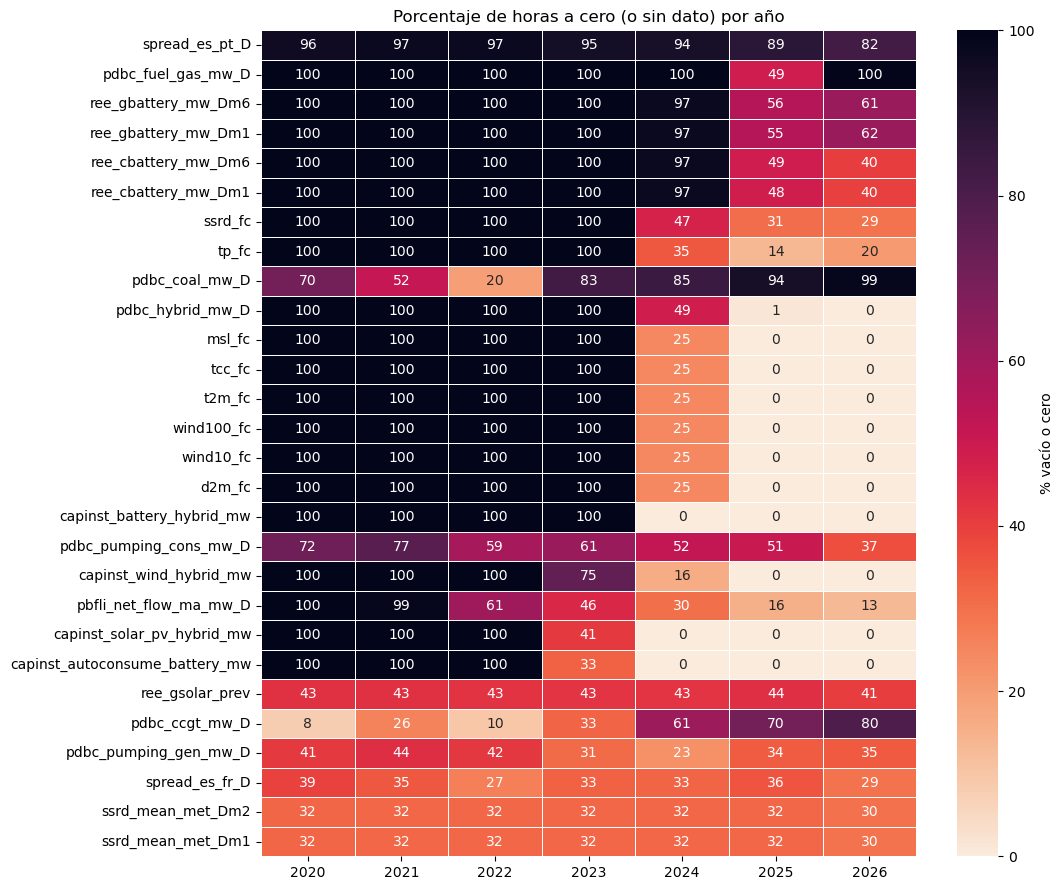

In [24]:
# Ceros por año y columna. Lo que se busca es la forma de "L": todo a cero y de pronto
# arranca. Una columna con ceros repartidos de forma pareja entre años es un cero real
# (la noche, el carbón parado); una con un bloque inicial sólido es un reloj disfrazado.
anio = pd.to_datetime(crudo["fecha_objetivo"]).dt.year
cols_z = [c for c in crudo.select_dtypes("number").columns
          if c in set(perfil["variable"])]
z = crudo[cols_z].isna() | crudo[cols_z].eq(0)      # en la cruda, NULL cuenta como "vacío"
peor = z.mean().sort_values(ascending=False).head(28).index

plt.figure(figsize=(11, 9))
sns.heatmap((z[peor].groupby(anio).mean() * 100).T, annot=True, fmt=".0f",
            cmap="rocket_r", vmin=0, vmax=100, cbar_kws={"label": "% vacío o cero"},
            linewidths=0.4)
plt.title("Porcentaje de horas a cero (o sin dato) por año")
plt.xlabel("")
plt.tight_layout()

### 9.2 · Por corte temporal: qué cuesta empezar la serie más tarde

La alternativa a podar columnas. Cada fecha de arranque candidata recupera unas columnas a
cambio de unas filas — y lo que hay que mirar no es cuántas columnas gana, sino **a qué
precio**.

,arranque,columnas_con_serie_completa,filas,pct_filas_perdidas,filas_train,cols_ganadas,train_perdido,filas_por_columna
0,2020-01-02,79,57665,0.0,43843,0,0,NaN
1,2020-01-03,118,57641,0.1,43819,39,24,1.0
2,2020-01-04,130,57617,0.1,43795,51,48,1.0
3,2020-01-08,151,57521,0.3,43699,72,144,2.0
4,2020-07-02,152,53298,7.6,39476,73,4367,60.0
5,2021-02-16,153,47802,17.1,33980,74,9863,133.0
6,2023-03-01,154,29972,48.0,16150,75,27693,369.0
7,2023-05-01,155,28509,50.6,14687,76,29156,384.0
8,2023-06-01,156,27765,51.9,13943,77,29900,388.0
9,2024-01-01,157,22629,60.8,8807,78,35036,449.0


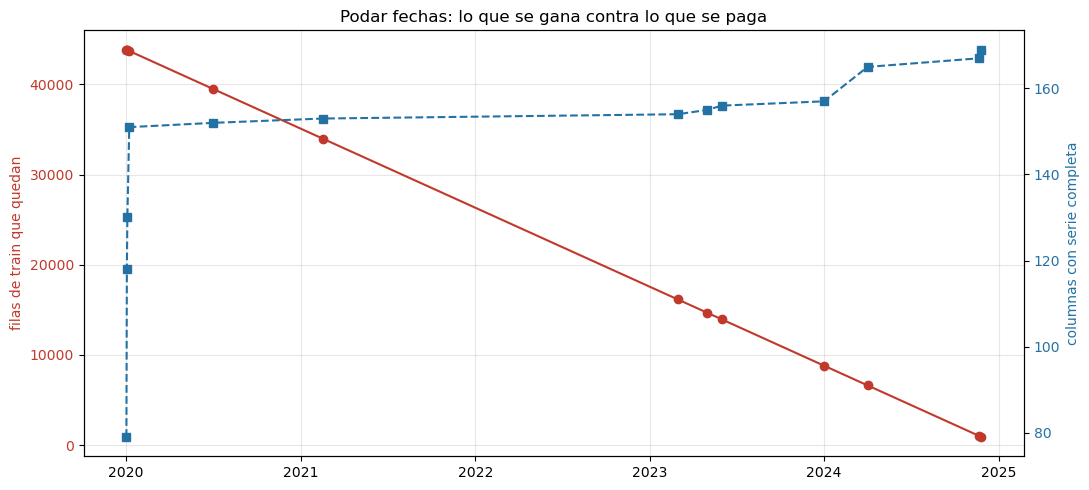

In [25]:
costes = corte_temporal(perfil, crudo)
base = costes.iloc[0]
costes["cols_ganadas"] = costes["columnas_con_serie_completa"] - base["columnas_con_serie_completa"]
costes["train_perdido"] = base["filas_train"] - costes["filas_train"]
costes["filas_por_columna"] = (costes["train_perdido"] /
                               costes["cols_ganadas"].replace(0, np.nan)).round(0)
display(costes)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pd.to_datetime(costes["arranque"]), costes["filas_train"], "o-", color="#c0392b")
ax.set_ylabel("filas de train que quedan", color="#c0392b")
ax.tick_params(axis="y", labelcolor="#c0392b")
ax2 = ax.twinx()
ax2.plot(pd.to_datetime(costes["arranque"]),
         costes["columnas_con_serie_completa"], "s--", color="#2471a3")
ax2.set_ylabel("columnas con serie completa", color="#2471a3")
ax2.tick_params(axis="y", labelcolor="#2471a3")
ax.set_title("Podar fechas: lo que se gana contra lo que se paga")
ax.grid(alpha=0.3)
plt.tight_layout()

### 9.3 · Las dos a la vez

El cruce es lo que decide. Para cada corte temporal, cuántas columnas sobreviven si además
se aplica la poda por arranque tardío.

In [26]:
f_crudo = pd.to_datetime(crudo["fecha_objetivo"])
tr_crudo = crudo["split"] == "train"
rejilla = []
for fecha in costes["arranque"]:
    ts = pd.Timestamp(fecha)
    quedan = f_crudo >= ts
    # una columna entra si su serie arranca a tiempo, o si arrancando tarde su tramo
    # fabricado ya cae fuera de la ventana recortada
    vivas = perfil[pd.to_datetime(perfil["arranca"]) <= ts]
    rejilla.append({
        "arranque": fecha,
        "inputs_disponibles": len(vivas),
        "filas": int(quedan.sum()),
        "filas_train": int((tr_crudo & quedan).sum()),
        "train_por_input": round(int((tr_crudo & quedan).sum()) / max(len(vivas), 1)),
    })
rejilla = pd.DataFrame(rejilla)
display(rejilla)

print("`train_por_input` es la lectura corta: cuántas filas de entrenamiento hay por")
print("cada variable disponible. Cuanto más alto, menos riesgo de sobreajuste.")

,arranque,inputs_disponibles,filas,filas_train,train_por_input
0,2020-01-02,79,57665,43843,555
1,2020-01-03,118,57641,43819,371
2,2020-01-04,130,57617,43795,337
3,2020-01-08,151,57521,43699,289
4,2020-07-02,152,53298,39476,260
5,2021-02-16,153,47802,33980,222
6,2023-03-01,154,29972,16150,105
7,2023-05-01,155,28509,14687,95
8,2023-06-01,156,27765,13943,89
9,2024-01-01,157,22629,8807,56


`train_por_input` es la lectura corta: cuántas filas de entrenamiento hay por
cada variable disponible. Cuanto más alto, menos riesgo de sobreajuste.


### 9.4 · Decisión

**Para la matriz principal se podan columnas, no fechas.** La tabla de 9.2 no deja lugar a
duda: cada fecha de arranque compra poquísimas columnas a cambio de muchísimas filas.
Retrasar el arranque a febrero de 2021 gana 2 columnas y cuesta 9.700 filas de train; llegar
a que *todas* las columnas tengan serie desde el primer día deja el entrenamiento en 912
filas. En ningún punto de la curva compensa.

**Pero la pregunta merece una matriz propia.** El sistema eléctrico de 2020 y el de 2026 no
se parecen — la solar se ha multiplicado, el carbón ha salido, las baterías están entrando —
así que no está dicho que seis años de historia valgan más que un año reciente y completo.
Eso no se decide por criterio: se decide por error de validación. Por eso una de las tres
matrices finales arranca en 2024 y recupera las columnas tardías.

`baja_cobertura` recoge las columnas que salen del pool por arrancar tarde, y es lo que la
sección 12 usa para componer `completa` y `nucleo`.

In [27]:
CORTE_RECIENTE = pd.Timestamp("2024-01-01")

# Fuera del pool de las matrices de historia larga: su tramo fabricado es demasiado grande.
baja_cobertura = sorted(tardias_todas["variable"])
baja_cobertura = [c for c in baja_cobertura if c in datos.columns]

# Recuperables en la matriz `reciente`: con la ventana recortada su serie ya está completa.
recuperables = sorted(
    perfil.loc[perfil.arranque_tardio
               & (pd.to_datetime(perfil["arranca"]) <= CORTE_RECIENTE), "variable"])
recuperables = [c for c in recuperables if c in datos.columns]

print(f"Fuera del pool por arranque tardío: {len(baja_cobertura)}")
for c in baja_cobertura:
    r = perfil[perfil.variable == c].iloc[0]
    print(f"    {c:32s} arranca {r['arranca']}  ({r['pct_sin_serie']}% sin serie)")
    anotar("9", c, "arranque tardío de la serie",
           f"{r['pct_sin_serie']}% de la ventana sin dato; el 0 sería un indicador temporal")

print()
print(f"Recuperables desde {CORTE_RECIENTE.date()}: {len(recuperables)}")
print(f"    {recuperables}")

Fuera del pool por arranque tardío: 7
    capinst_battery_hybrid_mw        arranca 2024-01-01  (60.8% sin serie)
    capinst_solar_pv_hybrid_mw       arranca 2023-06-01  (51.9% sin serie)
    capinst_wind_hybrid_mw           arranca 2023-03-01  (48.0% sin serie)
    ree_cbattery_mw_Dm1              arranca 2024-11-20  (74.3% sin serie)
    ree_cbattery_mw_Dm6              arranca 2024-11-25  (74.5% sin serie)
    ree_gbattery_mw_Dm1              arranca 2024-11-20  (74.3% sin serie)
    ree_gbattery_mw_Dm6              arranca 2024-11-25  (74.5% sin serie)

Recuperables desde 2024-01-01: 3
    ['capinst_battery_hybrid_mw', 'capinst_solar_pv_hybrid_mw', 'capinst_wind_hybrid_mw']


### 9.5 · Las baterías: el caso que hay que mirar de cerca

De las 7 que salen por arranque tardío, cuatro merecen su propio párrafo porque **no son
una columna inútil: son una columna muerta en train y viva en producción**, que es peor.

La serie de baterías arranca el 20-nov-2024. El protocolo cierra el entrenamiento el
31-dic-2024, así que en train hay 42 días de dato sobre seis años. Y la trampa está en que
esos 42 días son *identificables*: en entrenamiento, "batería ≠ 0" equivale exactamente a
"es diciembre de 2024".

Lo que el modelo haría con eso es aprender coeficiente ≈ 0 — o, peor, aprender la fecha — y
luego encontrarse en 2026 con una variable que sí importa y a la que no hace caso.

Y **sí importa**, que es lo que hace la decisión costosa en lugar de obvia.

In [28]:
bat = [c for c in datos.columns if "battery" in c]
filas = []
for c in bat:
    fila = {"variable": c}
    for s, m in (("train", TRAIN), ("validation", VAL), ("test", TEST)):
        fila[f"%!=0 {s}"] = round(float((datos.loc[m, c] != 0).mean()) * 100, 1)
    fila["corr train"] = round(float(datos.loc[TRAIN, c].corr(datos.loc[TRAIN, TARGET])), 3)
    fila["corr valid"] = round(float(datos.loc[VAL, c].corr(datos.loc[VAL, TARGET])), 3)
    filas.append(fila)
display(pd.DataFrame(filas))

nz = datos[TRAIN & (datos["ree_gbattery_mw_Dm1"] != 0)]
f_nz = pd.to_datetime(nz["fecha_objetivo"])
print(f"Filas de train con batería no nula: {len(nz):,} de {int(TRAIN.sum()):,} "
      f"({len(nz) / TRAIN.sum() * 100:.1f}%)")
print(f"Y todas caen entre {f_nz.min().date()} y {f_nz.max().date()}.")
print()
print("La lectura: r ~ 0.02 en train contra r ~ 0.35 en validación. La señal existe,")
print("pero está fuera de la ventana en la que el modelo puede aprenderla.")
print()
print("DECISIÓN: fuera de las tres matrices. No por falta de relevancia -- 0.35 supera")
print("a buena parte del pool -- sino por desajuste entre entrenamiento y servicio.")
print("Es una pérdida consciente y cuantificada, no un descarte por umbral.")
print()
print("RECUPERABLE: en cuanto el entrenamiento incluya 2025 -- que es lo que se hará al")
print("reentrenar para producción -- estas cuatro columnas dejan de tener el problema y")
print("deben volver. Conviene que el equipo lo tenga anotado.")

for c in bat:
    if c in baja_cobertura:
        anotar("9.5", c, "muerta en train, viva en producción",
               "señal real (r~0.35 en validación) pero <1% de filas no nulas en train")

,variable,%!=0 train,%!=0 validation,%!=0 test,corr train,corr valid
0,ree_gbattery_mw_Dm1,0.6,45.3,38.5,0.020,0.302
1,ree_cbattery_mw_Dm1,0.6,51.9,60.4,-0.006,0.356
2,ree_gbattery_mw_Dm6,0.6,44.4,38.5,0.034,0.294
3,ree_cbattery_mw_Dm6,0.6,51.0,59.7,-0.023,0.357
4,capinst_battery_hybrid_mw,20.2,100.0,100.0,-0.168,0.045


Filas de train con batería no nula: 246 de 43,699 (0.6%)
Y todas caen entre 2024-11-20 y 2025-01-01.

La lectura: r ~ 0.02 en train contra r ~ 0.35 en validación. La señal existe,
pero está fuera de la ventana en la que el modelo puede aprenderla.

DECISIÓN: fuera de las tres matrices. No por falta de relevancia -- 0.35 supera
a buena parte del pool -- sino por desajuste entre entrenamiento y servicio.
Es una pérdida consciente y cuantificada, no un descarte por umbral.

RECUPERABLE: en cuanto el entrenamiento incluya 2025 -- que es lo que se hará al
reentrenar para producción -- estas cuatro columnas dejan de tener el problema y
deben volver. Conviene que el equipo lo tenga anotado.


## 10 · Redundancia

Cada par muy correlacionado es una elección pendiente. Con 219 columnas de partida la
redundancia es masiva y en parte deliberada (dos fuentes para la misma magnitud, un
total que es suma de sus partes). Listarla hace que la elección sea explícita.

In [29]:
redundancia = dep.bloques_correlacion(datos[TRAIN], variables_input, umbral=0.95)
red_anotada = con_origen_pares(redundancia)
print(f"Pares con |r| >= 0.95: {len(redundancia)}")
print(f"  dentro de la MISMA tabla : {red_anotada['mismo_origen'].sum()}  (duplicidad de la fuente)")
print(f"  entre tablas DISTINTAS   : {(~red_anotada['mismo_origen']).sum()}  (dos fuentes miden lo mismo)")
display(red_anotada.head(30).round(4))

Pares con |r| >= 0.95: 52
  dentro de la MISMA tabla : 49  (duplicidad de la fuente)
  entre tablas DISTINTAS   : 3  (dos fuentes miden lo mismo)


,var_a,var_b,correlacion,origen_a,origen_b,mismo_origen
0,bil_total_sales_mw_D,bil_total_purchases_mw_D,1.0000,esios_pbf_bilateral,esios_pbf_bilateral,True
1,capinst_total_nonrenewable_mw,capinst_coal_mw,1.0000,esios_capacity_installed,esios_capacity_installed,True
2,capinst_total_renewable_mw,capinst_solar_pv_mw,0.9987,esios_capacity_installed,esios_capacity_installed,True
3,bil_total_sales_mw_D,bil_retail_free_buy_mw_D,0.9961,esios_pbf_bilateral,esios_pbf_bilateral,True
4,bil_total_purchases_mw_D,bil_retail_free_buy_mw_D,0.9961,esios_pbf_bilateral,esios_pbf_bilateral,True
5,tp_acum_30d_met_Dm1,tp_acum_30d_met_Dm2,0.9948,era5_weather_agg,era5_weather_agg,True
6,capinst_total_mw,capinst_solar_pv_mw,0.9944,esios_capacity_installed,esios_capacity_installed,True
7,capinst_total_autoconsume_mw,capinst_solar_pv_mw,0.9935,esios_capacity_installed,esios_capacity_installed,True
8,capinst_solar_pv_hybrid_mw,capinst_battery_hybrid_mw,0.9912,esios_capacity_installed,esios_capacity_installed,True
9,capinst_total_mw,capinst_total_autoconsume_mw,0.9894,esios_capacity_installed,esios_capacity_installed,True


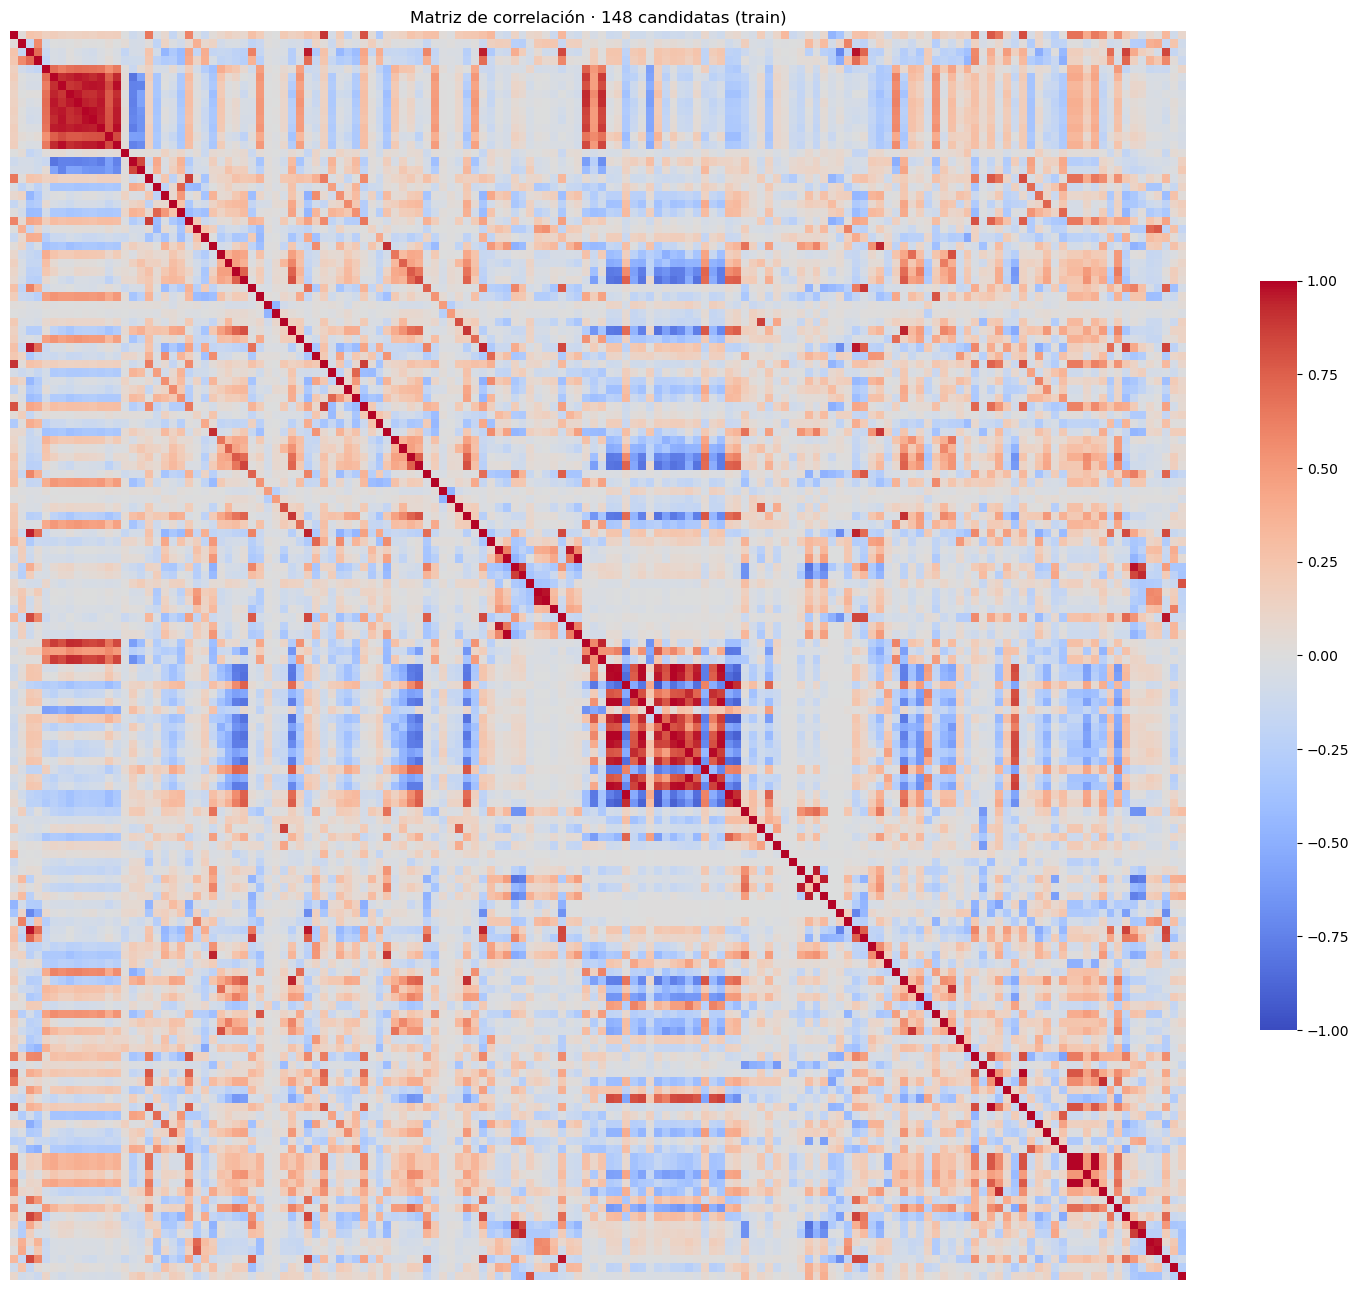

In [30]:
cols_corr = [c for c in variables_input if datos.loc[TRAIN, c].notna().mean() > 0.9]
plt.figure(figsize=(15, 13))
sns.heatmap(datos.loc[TRAIN, cols_corr].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.6}, xticklabels=False, yticklabels=False)
plt.title(f"Matriz de correlación · {len(cols_corr)} candidatas (train)")
plt.tight_layout()

## 11 · Importancia frente al objetivo

El gráfico de V de Cramer de la sección 7.2 de la tarea de clase. Tres medidas, porque
discrepar es informativo: Pearson (lineal), Spearman (monótona) y V de Cramer
(asociación sobre quintiles, capta formas de U o escalón).

Mide **asociación, no aporte incremental**: una variable con V de Cramer alto puede no
sumar nada si otra ya lleva esa información. Se lee junto a la sección 10.

In [31]:
ranking = dep.ranking_asociacion(datos[TRAIN], variables_input, TARGET)
display(con_origen(ranking).head(30).round(3))
print("Mejor V de Cramer por tabla de origen:")
print(con_origen(ranking).groupby("tabla_origen")["v_cramer"].agg(
    columnas="size", mejor="max", mediana="median").round(3)
    .sort_values("mejor", ascending=False).to_string())

,variable,tabla_origen,bloque,pearson,spearman,v_cramer,n_pares,abs_pearson
0,pt_entsoe_D,"spot_price (Europa, dia D)",precio,0.918,0.895,0.649,43699,0.918
1,capinst_coal_mw,esios_capacity_installed,capacidad,-0.284,-0.154,0.503,43699,0.284
2,fr_entsoe_D,"spot_price (Europa, dia D)",precio,0.669,0.777,0.500,43699,0.669
3,capdisp_coal_antracita_mw,esios_capacity_available,capacidad,-0.332,-0.379,0.490,43699,0.332
4,gas_mibgas,commodities,combustibles,0.731,0.752,0.486,43699,0.731
5,it_nord_entsoe_D,"spot_price (Europa, dia D)",precio,0.658,0.762,0.472,43699,0.658
6,be_entsoe_D,"spot_price (Europa, dia D)",precio,0.662,0.744,0.469,43699,0.662
7,ch_entsoe_D,"spot_price (Europa, dia D)",precio,0.679,0.757,0.466,43699,0.679
8,gas_ttf_m1,commodities,combustibles,0.634,0.736,0.463,43699,0.634
9,at_entsoe_D,"spot_price (Europa, dia D)",precio,0.642,0.754,0.460,43699,0.642


Mejor V de Cramer por tabla de origen:
                            columnas  mejor  mediana
tabla_origen                                        
spot_price (Europa, dia D)        10  0.649    0.463
esios_capacity_installed          17  0.503    0.409
esios_capacity_available           5  0.490    0.138
commodities                        3  0.486    0.463
esios_pdbc_gen                    14  0.417    0.218
esios_pbf_gen                      4  0.322    0.104
generation (real D-1/D-6)         44  0.303    0.134
esios_pbf_bilateral                8  0.282    0.192
esios_pbf_load_inter              10  0.194    0.103
spot_price (lag)                   3  0.194    0.175
CALENDARIO (calculado)             8  0.181    0.104
era5_weather_agg                  18  0.164    0.099
forecast                           4  0.149    0.139


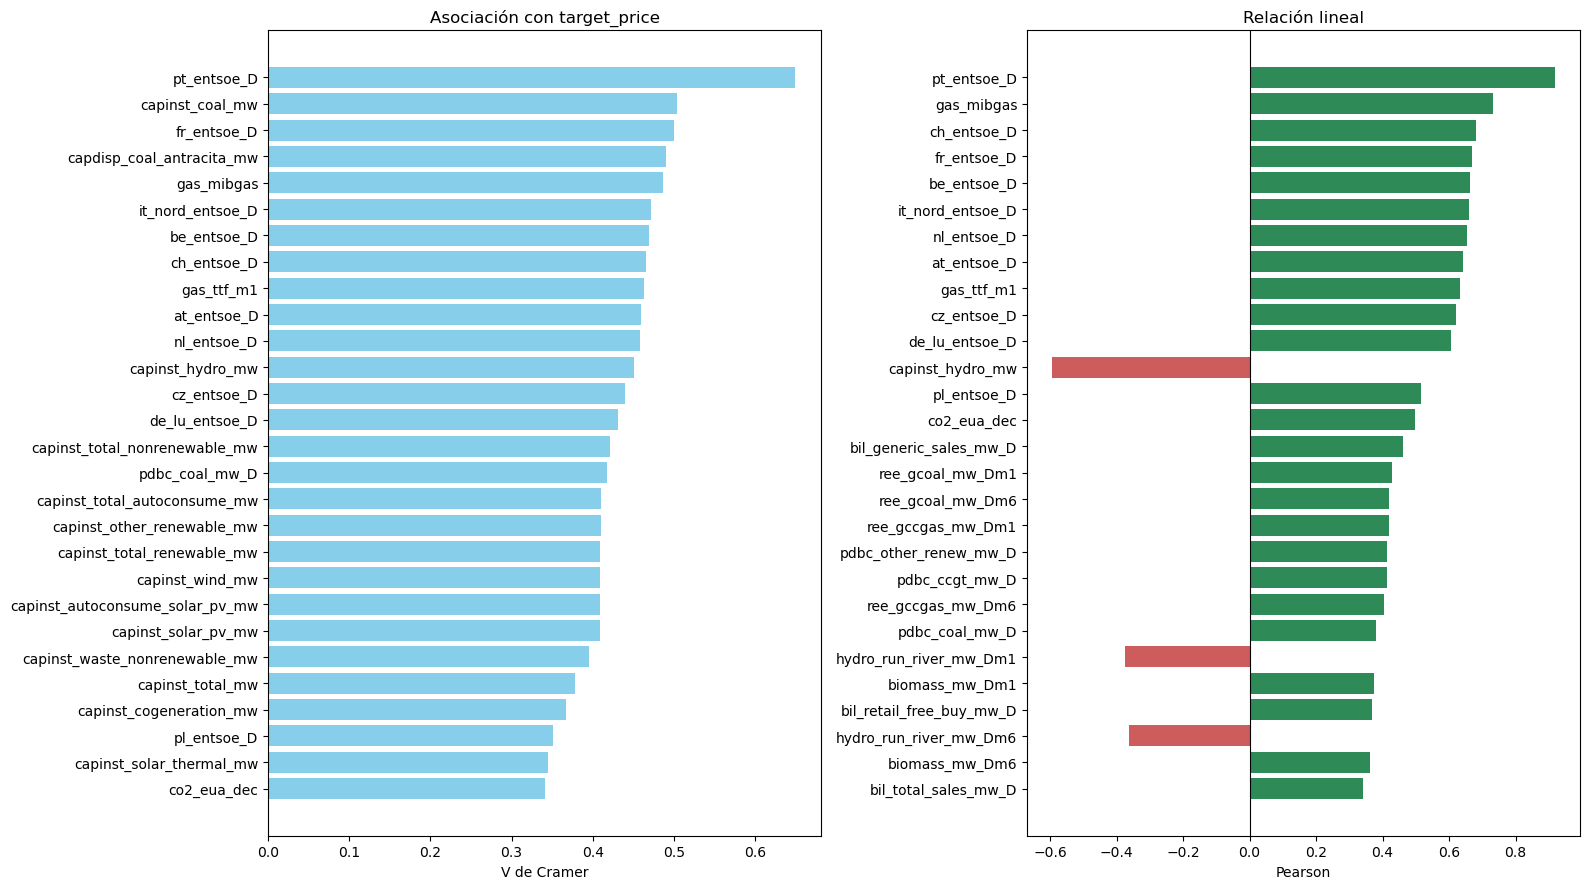

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(16, 9))
top = ranking.dropna(subset=["v_cramer"]).head(28).iloc[::-1]
ax[0].barh(top["variable"], top["v_cramer"], color="skyblue")
ax[0].set_xlabel("V de Cramer"); ax[0].set_title("Asociación con target_price")
top_p = ranking.sort_values("abs_pearson", ascending=False).head(28).iloc[::-1]
ax[1].barh(top_p["variable"], top_p["pearson"],
           color=["indianred" if v < 0 else "seagreen" for v in top_p["pearson"]])
ax[1].axvline(0, color="black", lw=0.8)
ax[1].set_xlabel("Pearson"); ax[1].set_title("Relación lineal")
plt.tight_layout()

In [33]:
# ¿Cuánto aporta cada bloque nuevo? El PDBC entró para sustituir a la media diaria que
# traía el constructor, así que lo que hay que ver es si el grano horario paga.
BLOQUES_NUEVOS = {
    "pdbc_ (casación por tecnología)": "pdbc_",
    "pbfli_ (demanda e interconexión)": "pbfli_",
    "bil_ (bilaterales de intermediación)": "bil_",
}
rk = ranking.reset_index(drop=True)
for etiqueta, pre in BLOQUES_NUEVOS.items():
    sub = rk[rk["variable"].str.startswith(pre)]
    if not len(sub):
        print(f"{etiqueta}: ninguna columna en el pool")
        continue
    mejor = sub.loc[sub["v_cramer"].idxmax()]
    pos = int(rk.index[rk["variable"] == mejor["variable"]][0]) + 1
    print(f"{etiqueta}")
    print(f"    columnas en el pool : {len(sub)}")
    print(f"    mejor V de Cramer   : {mejor['v_cramer']:.3f}  ({mejor['variable']})")
    print(f"    su puesto global    : {pos} de {len(rk)}")
    print(f"    mediana del bloque  : {sub['v_cramer'].median():.3f}   "
          f"(mediana global {rk['v_cramer'].median():.3f})")
    print()

nuevos = rk[rk["variable"].str.startswith(tuple(BLOQUES_NUEVOS.values()))]
display(nuevos.head(15).round(3))

pdbc_ (casación por tecnología)
    columnas en el pool : 18
    mejor V de Cramer   : 0.417  (pdbc_coal_mw_D)
    su puesto global    : 16 de 148
    mediana del bloque  : 0.199   (mediana global 0.155)

pbfli_ (demanda e interconexión)
    columnas en el pool : 10
    mejor V de Cramer   : 0.194  (pbfli_demand_aux_mw_D)
    su puesto global    : 59 de 148
    mediana del bloque  : 0.103   (mediana global 0.155)

bil_ (bilaterales de intermediación)
    columnas en el pool : 8
    mejor V de Cramer   : 0.282  (bil_direct_consumer_mw_D)
    su puesto global    : 33 de 148
    mediana del bloque  : 0.192   (mediana global 0.155)



,variable,pearson,spearman,v_cramer,n_pares,abs_pearson
15,pdbc_coal_mw_D,0.380,0.471,0.417,43699,0.380
28,pdbc_pumping_cons_mw_D,0.274,0.308,0.322,43699,0.274
30,pdbc_ccgt_mw_D,0.413,0.480,0.296,43699,0.413
32,bil_direct_consumer_mw_D,-0.042,0.204,0.282,43699,0.042
34,pdbc_other_renew_mw_D,0.413,0.378,0.255,43699,0.413
40,bil_generic_sales_mw_D,0.462,0.387,0.242,43699,0.462
41,pdbc_cogen_mw_D,0.056,-0.030,0.240,43699,0.056
43,pdbc_hydro_no_ugh_mw_D,-0.315,-0.390,0.233,43699,0.315
45,pdbc_nuclear_mw_D,-0.254,-0.309,0.229,43699,0.254
49,pdbc_biogas_mw_D,0.288,0.266,0.218,43699,0.288


## 12 · Matrices candidatas

Cuatro, y el diseño no es casual: **las tres primeras varían las columnas con la ventana
fija, y la cuarta varía la ventana con las columnas fijas.** Así cada comparación aísla un
factor y el resultado se puede interpretar; si se movieran las dos cosas a la vez, un error
mejor no diría de dónde viene.

| matriz | ventana | inputs | qué aísla |
|---|---|---|---|
| `completa` | 2020 → | todo el pool menos las tardías | — (referencia) |
| `nucleo` | 2020 → | sin redundantes ni derivadas | ¿sobran variables? |
| `minima` | 2020 → | las 25 mejores del ranking | ¿bastan muy pocas? |
| `moderna` | **2023 →** | las del núcleo | **¿estorba la crisis del gas?** |

`moderna` merece la explicación. El 40 % del entrenamiento es un régimen de precios que no
va a volver: 2022 promedió 167,5 €/MWh, **2,66 veces** los 63,0 de 2024, y el tope al gas
estuvo activo el 55 % de 2022 y el 100 % de 2023. Un modelo ajustado sobre eso aprende la
crisis tanto como el mercado.

El corte va en enero de 2023 y no en otro sitio porque se midió. Sobre los cinco cortes
posibles, 2023 tiene la segunda menor confusión fecha-precio (−0,130, sólo por detrás de la
ventana entera con 0,085) y deja una única columna de capacidad convertida en reloj. Cortar
en 2022 sería lo peor posible — confusión de −0,613 y tres relojes — y cortar en 2024 deja
8.807 filas de train con una tendencia de 0,479, que es lo que hundió la variante
`reciente` que se descartó (ver 9.5 y el apartado de abierto).

2023 entra entero bajo el tope al gas, pero eso el modelo lo puede distinguir:
`d1_regimen_tope_gas` va como feature.

In [34]:
# De cada par redundante sobrevive el de mayor V de Cramer.
vc = ranking.set_index("variable")["v_cramer"].to_dict()
descartar_red = set()
for _, r in redundancia.iterrows():
    a, b = r["var_a"], r["var_b"]
    if a in descartar_red or b in descartar_red:
        continue
    descartar_red.add(b if vc.get(a, 0) >= vc.get(b, 0) else a)

print(f"Descartadas por redundancia      : {len(descartar_red)}")
print(f"Descartadas por deriva > {UMBRAL_DERIVA} sigma : {len(muy_derivadas)}")
print(f"Descartadas por arranque tardío  : {len(baja_cobertura)}")

# `completa` ya excluye las tardías: su 0 sería un indicador temporal (secciones 9 y 9.5).
completa_inputs = [c for c in variables_input if c not in baja_cobertura]
nucleo_inputs = [c for c in completa_inputs
                 if c not in descartar_red and c not in muy_derivadas]
minima_inputs = [c for c in ranking["variable"] if c in nucleo_inputs][:25]
moderna_inputs = list(nucleo_inputs)          # mismo pool: la variación es la ventana

CORTE_MODERNA = pd.Timestamp("2023-01-01")

print()
print(f"Pool bruto : {len(variables_input)}")
print(f"completa   : {len(completa_inputs)}")
print(f"nucleo     : {len(nucleo_inputs)}")
print(f"minima     : {len(minima_inputs)}")
print(f"moderna    : {len(moderna_inputs)}  (idéntico al núcleo, desde {CORTE_MODERNA.date()})")

Descartadas por redundancia      : 27
Descartadas por deriva > 3.0 sigma : 12
Descartadas por arranque tardío  : 7

Pool bruto : 148
completa   : 141
nucleo     : 112
minima     : 25
moderna    : 112  (idéntico al núcleo, desde 2023-01-01)


In [35]:
COMUNES = COLS_CONTROL + [TARGET] + persistencia + COLS_CATEGORICAS + COLS_BANDERA
SALIDA_DIR.mkdir(parents=True, exist_ok=True)

MATRICES = {"completa": completa_inputs, "nucleo": nucleo_inputs,
            "minima": minima_inputs, "moderna": moderna_inputs}
todo = pd.Series(True, index=datos.index)
FILAS = {"completa": todo, "nucleo": todo, "minima": todo,
         "moderna": datos["fecha_objetivo"] >= CORTE_MODERNA}
AISLA = {"completa": "referencia",
         "nucleo": "columnas (¿sobran variables?)",
         "minima": "columnas (¿bastan 25?)",
         "moderna": "ventana (¿estorba la crisis del gas?)"}

resumen = []
for nombre, inputs in MATRICES.items():
    cols = list(dict.fromkeys([c for c in COMUNES + inputs if c in datos.columns]))
    m = datos.loc[FILAS[nombre], cols].copy()
    ruta = SALIDA_DIR / f"matriz_{nombre}.parquet"
    m.to_parquet(ruta, index=False)
    # CSV al lado del parquet: el parquet es el formato de trabajo -- conserva tipos y
    # pesa la cuarta parte -- pero el CSV se abre desde cualquier sitio sin dependencias,
    # que es lo que hace falta para revisarlo a mano o pasarlo a alguien.
    m.to_csv(ruta.with_suffix(".csv"), index=False, encoding="utf-8")
    meta = {
        "nombre": nombre,
        "aisla": AISLA[nombre],
        "origen": "Postgres vía construir_matriz.construir()",
        "bloque_generacion": ("PDBC horario leído de esios_pdbc_gen; el bombeo de "
                              "esios_pbf_gen, donde los ceros están intactos"),
        "filas": int(len(m)), "columnas": int(m.shape[1]), "n_inputs": len(inputs),
        "reparto": {k: int(v) for k, v in m["split"].value_counts().items()},
        "train_end": "2024-12-31", "val_end": "2025-12-31",
        "ventana": f"{m['fecha_objetivo'].min().date()} -> {m['fecha_objetivo'].max().date()}",
        "apagon": ("ventana 28-abr 12:00 -> 1-may 23:00 sustituida en bloque desde D-7, "
                   "todas las columnas incluido el precio; resaca 2-may -> 7-may sólo "
                   "rellenando huecos. Marcado en imputado_apagon y ventana_pisa_apagon"),
        "meteorologia": ("canal empalmado *_meteo: previsión ECMWF desde 2024-04, ERA5 "
                         "desfasado antes. meteo_es_forecast indica cuál"),
        "nulos": int(m.isna().sum().sum()),
        "imputacion": ("por lo que significa cada hueco: NULL=0 donde la fuente no escribe "
                       "ceros, escalón donde la tecnología no existía, ffill en capacidad y "
                       "commodities, interpolación <=3h, análogo D-7 en huecos largos. "
                       "Ninguna celda por media ni mediana"),
        "excluidas_por_arranque_tardio": baja_cobertura,
        "catalogo_columnas": f"matriz_{nombre}_columnas.csv",
        "origenes": resumen_origen(cols).set_index("tabla_origen")["columnas"].to_dict(),
    }
    ruta.with_suffix(".meta.json").write_text(
        json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
    catalogo(cols).to_csv(SALIDA_DIR / f"matriz_{nombre}_columnas.csv",
                          index=False, encoding="utf-8")
    resumen.append(meta)
    tr = int(meta["reparto"].get("train", 0))
    mb_p = ruta.stat().st_size / 1e6
    mb_c = ruta.with_suffix(".csv").stat().st_size / 1e6
    print(f"  {nombre:9s} {len(m):>6,} x {m.shape[1]:3d}  inputs {len(inputs):3d}  "
          f"train {tr:>6,}  nulos {meta['nulos']}  "
          f"[{mb_p:.0f} MB parquet / {mb_c:.0f} MB csv]   <- {AISLA[nombre]}")

print()
print("Las cuatro salen sin un solo nulo. `moderna` es la única que cambia la ventana,")
print("y lleva el mismo pool que `nucleo` para que la comparación entre ambas mida")
print("sólo el efecto de quitar 2020-2022.")
pd.DataFrame(resumen)[["nombre", "aisla", "filas", "columnas", "n_inputs", "nulos"]]

  completa  57,521 x 161  inputs 141  train 43,699  nulos 0  [28 MB parquet / 79 MB csv]   <- referencia


  nucleo    57,521 x 132  inputs 112  train 43,699  nulos 0  [22 MB parquet / 62 MB csv]   <- columnas (¿sobran variables?)


  minima    57,521 x  45  inputs  25  train 43,699  nulos 0  [4 MB parquet / 15 MB csv]   <- columnas (¿bastan 25?)


  moderna   31,388 x 132  inputs 112  train 17,566  nulos 0  [13 MB parquet / 34 MB csv]   <- ventana (¿estorba la crisis del gas?)

Las cuatro salen sin un solo nulo. `moderna` es la única que cambia la ventana,
y lleva el mismo pool que `nucleo` para que la comparación entre ambas mida
sólo el efecto de quitar 2020-2022.


,nombre,aisla,filas,columnas,n_inputs,nulos
0,completa,referencia,57521,161,141,0
1,nucleo,columnas (¿sobran variables?),57521,132,112,0
2,minima,columnas (¿bastan 25?),57521,45,25,0
3,moderna,ventana (¿estorba la crisis del gas?),31388,132,112,0


In [36]:
# Bitácora de descartes: el documento que va a la memoria.
bit = con_origen(pd.DataFrame(bitacora), posicion=2)
ruta_bit = SALIDA_DIR / "bitacora_depuracion.csv"
bit.to_csv(ruta_bit, index=False, encoding="utf-8")
print(f"Bitácora -> {ruta_bit.relative_to(REPO)}  ({len(bit)} entradas)")
print()
print(bit.groupby(["seccion", "motivo"]).size().rename("columnas").to_string())
print()
print("Descartes por tabla de origen:")
print(bit.groupby("tabla_origen").size().rename("columnas")
        .sort_values(ascending=False).to_string())

Bitácora -> data\gold\bitacora_depuracion.csv  (32 entradas)

seccion  motivo                              
5.2      constante en train                       1
         cuasi-constante en train                 3
5.4      sin equivalente en produccion            2
8        NULL = 0 por convención de la fuente    14
9        arranque tardío de la serie              7
9.5      muerta en train, viva en producción      5

Descartes por tabla de origen:
tabla_origen
generation (real D-1/D-6)    12
esios_pbf_bilateral           8
esios_capacity_installed      5
era5_weather_agg              2
esios_pbf_load_inter          2
CALENDARIO (calculado)        1
esios_capacity_available      1
esios_pdbc_gen                1


In [37]:
print("Composición de cada matriz por bloque de origen:")
comp = pd.concat({n: resumen_origen(
    [c for c in COMUNES + i if c in datos.columns]).set_index("tabla_origen")["columnas"]
    for n, i in MATRICES.items()}, axis=1).fillna(0).astype(int)
display(comp)

control = registrar("12 · matriz completa", datos, [TARGET] + variables_input + COLS_CATEGORICAS)
control["nulas_dif"] = control["celdas_nulas"].diff().fillna(0).astype(int)
control["cols_dif"] = control["columnas"].diff().fillna(0).astype(int)
control

Composición de cada matriz por bloque de origen:


,completa,nucleo,minima,moderna
tabla_origen,,,,
CALENDARIO (calculado),14,12,6,12
esios_capacity_installed,14,4,4,4
esios_capacity_available,5,5,1,5
esios_pdbc_gen,14,12,3,12
esios_pbf_gen,4,4,1,4
commodities,3,3,3,3
CLAVE,5,5,5,5
era5_weather_agg,18,12,0,12
spot_price (TARGET),1,1,1,1


,etapa,filas,columnas,celdas_nulas,filas_con_nulo,nulas_dif,cols_dif
0,0 · carga v04,57689,192,659245,49796,0,0
1,2.1 · apagón imputado,57689,194,657300,49679,-1945,2
2,2.2 · depurada,57521,181,0,0,-657300,-13
3,3 · tipado,57521,166,0,0,0,-15
4,5.2 · constantes,57521,162,0,0,0,-4
5,5.3 · colinealidad exacta,57521,162,0,0,0,0
6,5.4 · racha de viento,57521,160,0,0,0,-2
7,8 · sin nulos,57521,181,0,0,0,21
8,12 · matriz completa,57521,157,0,0,0,-24


### Comprobación del protocolo

Lo último antes de cerrar: verificar que ninguna decisión miró 2026.

In [38]:
comprobaciones = {
    "descriptivos calculados sobre": "train",
    "deriva medida contra": "validation (2025)",
    "ranking y redundancia sobre": "train",
    "umbral de constantes sobre": "train",
    "perfil de ceros medido sobre": "la matriz CRUDA (antes de imputar)",
}
for k, v in comprobaciones.items():
    print(f"  {k:34s} {v}")

n26 = int(TEST.sum())
print()
print(f"Filas de 2026 en los ficheros: {n26:,} (viajan, pero no se han leído)")
print("Split: train <= 2024-12-31 · validation 2025 · test 2026")

# 2025 tiene que estar COMPLETO: el apagón se imputó, no se borró.
dias_2025 = datos.loc[datos["fecha_objetivo"].dt.year == 2025, "fecha_objetivo"].nunique()
print()
print(f"Días de 2025 presentes: {dias_2025} de 365  "
      f"-> validación completa: {'SÍ' if dias_2025 == 365 else 'NO'}")

tocadas = int((datos["imputado_apagon"] > 0).sum())
pisan = int(datos["ventana_pisa_apagon"].sum())
print(f"Filas con celdas del análogo D-7 : {tocadas}")
print(f"Filas cuyos lags pisan la ventana: {pisan} (dato real, solo marcadas)")
print()
print("Ninguna fila se ha borrado por el apagón. Quien evalúe puede excluir las")
print("marcadas; la matriz no toma esa decisión por él.")

  descriptivos calculados sobre      train
  deriva medida contra               validation (2025)
  ranking y redundancia sobre        train
  umbral de constantes sobre         train
  perfil de ceros medido sobre       la matriz CRUDA (antes de imputar)

Filas de 2026 en los ficheros: 5,063 (viajan, pero no se han leído)
Split: train <= 2024-12-31 · validation 2025 · test 2026

Días de 2025 presentes: 365 de 365  -> validación completa: SÍ
Filas con celdas del análogo D-7 : 214
Filas cuyos lags pisan la ventana: 228 (dato real, solo marcadas)

Ninguna fila se ha borrado por el apagón. Quien evalúe puede excluir las
marcadas; la matriz no toma esa decisión por él.


## Qué queda abierto

1. **`ERA5_MODO` admite un valor que es fuga.** El constructor permite `"perfecto"`, que
   mete el tiempo real del día D+1 para la ablación de cota superior. Este notebook usa
   solo el modo `lag`, pero conviene que el equipo sepa que ese flag existe antes de
   cerrar modelos el domingo.

2. **El alineamiento `_D` del PBF** está por confirmar con el equipo. El notebook usa el
   PBF del propio día D (disponible a las 12:00 de D, publicado a las 13:45 de D-1);
   `bloque_para_matriz(pbf, alineamiento="Dm1")` da la versión conservadora.

3. **Los días del apagón siguen dentro de validación, ya imputados.** Es deliberado: así
   2025 está completo, como pide el protocolo. La ventana se sustituyó en bloque desde
   D-7 y la resaca se rellenó solo en los huecos; quien evalúe decide si excluye esas
   filas, y tiene `imputado_apagon` y `ventana_pisa_apagon` para hacerlo con criterio.

4. **La variante `reciente` (desde 2024) se probó y se descartó**, y conviene que conste
   por qué: de las 7 columnas tardías que iba a recuperar sólo recupera 3, y de esas sólo
   `capinst_wind_hybrid_mw` sobrevive al test de reloj. Encima su train de un solo año
   tiene una correlación fecha-precio de 0,479 — frente a 0,085 en la ventana entera — que
   convierte en trampa 19 columnas de capacidad instalada perfectamente sanas en la serie
   larga. Pagaba 35.000 filas de train por una columna y estropeaba otras diecinueve. Su
   sitio lo ocupa `moderna`, que corta en 2023 con una confusión de sólo −0,130.

5. **`moderna` contra `nucleo` es la primera comparación que hay que mirar al entrenar.**
   Con todo lo demás idéntico, mide si los 26.000 registros de 2020-2022 ayudan o estorban.
   Si `moderna` gana, el TFM tiene un resultado que contar.